# Walrasian Tâtonnement — Setup

Modular implementation of the tâtonnement algorithm for the social planner's problem.

**Two-loop architecture:**
- **Outer loop**: prices $(p, w, r, \beta)$, production, households, infrastructure.
- **Inner loop**: flows $(Q^s_{ij}, q^s_{ij}, \hat{Q}_{nn'}, \gamma_{nn'})$ at fixed outer prices.

This notebook contains only the **setup**: data structures, parameters, block functions. The loops will be implemented in a second step.

In [138]:
import numpy as np
import heapq
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Callable
from abc import ABC, abstractmethod
from collections import deque
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. Data structures

We define three dataclasses:
- `Network`: topology of the transport network (nodes, edges, infrastructure).
- `ModelParams`: economic parameters (Cobb-Douglas, endowments, transport).
- `State`: current state (prices, quantities, flows) — updated at each iteration. 

In [139]:
""" Useful tools """
def _logsumexp(x):
    x = np.asarray(x).ravel()
    m = np.max(x)
    if not np.isfinite(m):
        return m
    return m + np.log(np.sum(np.exp(x - m)))

In [140]:
class Functions(ABC):
    @abstractmethod
    def __call__(self, *args, **kwargs):
        pass

    @abstractmethod
    def gradient(self, *args, **kwargs):
        pass


class ProductionFunction(Functions):
    @abstractmethod
    def invert(*args, **kwargs):
        """Given prices p, compute the inputs H, L, Q_inp."""
        pass


class UtilityFunction(Functions):
    @abstractmethod
    def invert(*args, **kwargs):
        """Given prices, compute the consumption c,  land l and leisure time."""
        pass

class TauLink(Functions):
    pass

class TimeLink(Functions):
    pass

**Examples of functions**

In [141]:
class CobbDouglasUtility(UtilityFunction):
    """
    U^s(c, l) = sum_k alpha_c[s,k] * log(c_k) + alpha_l[s] * log(l) + alpha_f[s]*log(f).
    alpha_c: (S, S) — alpha_c[s, k] = weight of good k in sector-s utility.
    alpha_l: (S,)
    alpha_f: (S,)
    """
    def __init__(self, alpha_c: np.ndarray, alpha_l: np.ndarray, alpha_f: np.ndarray):
        self.alpha_c = np.asarray(alpha_c, dtype=float)
        self.alpha_l = np.asarray(alpha_l, dtype=float)
        self.alpha_f = np.asarray(alpha_f, dtype=float)

    def __call__(self, c, l, f, s, i=None, j=None):
        c = np.asarray(c)
        return float(np.sum(self.alpha_c[s] * np.log(c)) + self.alpha_l[s] * np.log(l) + self.alpha_f[s] * np.log(f))

    def gradient(self, c, l, f, s, i=None, j=None):
        c = np.asarray(c)
        return self.alpha_c[s] / c, self.alpha_l[s] / l, self.alpha_f[s] / f   # (dU/dc, dU/dl, dU/df)

    def invert(self, p_i, r_i, w_s, s, i=None, j=None):
        c = self.alpha_c[s] / p_i           # shape (S,)
        l = self.alpha_l[s] / r_i
        f = self.alpha_f[s] / w_s           # shape (S,)
        return c, l, f

class CobbDouglasProduction(ProductionFunction):
    """
    Y = A * H^aH * L^aL * prod_k Q_k^{aQ_k}, with sum(a) < 1.
    A:     (S, J)
    aH:    (S,)
    aL:    (S,)
    aQ:    (S, S)  — aQ[s, k] = elasticity of good k in sector-s production.
    """
    def __init__(self, A: np.ndarray, aH: np.ndarray, aL: np.ndarray, aQ: np.ndarray):
        self.A  = np.asarray(A,  dtype=float)
        self.aH = np.asarray(aH, dtype=float)
        self.aL = np.asarray(aL, dtype=float)
        self.aQ = np.asarray(aQ, dtype=float)
        assert np.all(self.aH + self.aL + self.aQ.sum(axis=1) < 1), \
            "Cobb-Douglas requires decreasing returns (sum of elasticities < 1)."

    def __call__(self, H, L, Q_inp, s, j):
        Q_inp = np.asarray(Q_inp, dtype=float)
        # 0**0 = 1 by convention
        prodQ = np.prod(np.where(self.aQ[s] > 0, Q_inp ** self.aQ[s], 1.0))
        return float(self.A[s, j] * H ** self.aH[s] * L ** self.aL[s] * prodQ)

    def gradient(self, H, L, Q_inp, s, j, var=None):
        Y = self(H, L, Q_inp, s, j)
        if var == 'H':     return self.aH[s] * Y / H
        if var == 'L':     return self.aL[s] * Y / L
        if var == 'Q':
            Q_inp = np.asarray(Q_inp, dtype=float)
            return np.where(Q_inp > 0, self.aQ[s] * Y / np.where(Q_inp > 0, Q_inp, 1.0), 0.0)
        # default: return all
        return self.aH[s] * Y / H, self.aL[s] * Y / L, self.aQ[s] * Y / Q_inp

    def invert(self, p_sj, p_vec, w_s, r_j, s, j, H_sj=None):
        aH, aL, aQ = self.aH[s], self.aL[s], self.aQ[s]
        S_sum = aH + aL + aQ.sum()

        log_Y  = np.log(self.A[s, j]) + S_sum * np.log(p_sj)
        log_Y += aH * np.log(aH / w_s) + aL * np.log(aL / r_j)
        # 0 * log(0) = 0
        mask = aQ > 0
        log_Y += np.sum(aQ[mask] * np.log(aQ[mask] / p_vec[mask]))
        log_Y /= (1.0 - S_sum)

        Y = np.exp(log_Y)
        H = aH * Y * p_sj / w_s
        L = aL * Y * p_sj / r_j
        Q_inp = np.zeros_like(p_vec)
        Q_inp[mask] = aQ[mask] * Y * p_sj / p_vec[mask]
        return Y, H, L, Q_inp
    
class CobbDouglasCrsProduction(ProductionFunction):
    """
    Y = A * H^aH * L^aL * prod_k Q_k^{aQ_k}, with sum(a) = 1.
    A:     (S, J)
    aH:    (S,)
    aL:    (S,)
    aQ:    (S, S)  — aQ[s, k] = elasticity of good k in sector-s production.
    """

    def __init__(self, A: np.ndarray, aH: np.ndarray, aL: np.ndarray, aQ: np.ndarray):
        self.A   = np.asarray(A,  dtype=float)
        self.aH  = np.asarray(aH, dtype=float)
        self.aL  = np.asarray(aL, dtype=float)
        self.aQ  = np.asarray(aQ, dtype=float)
        assert np.all(self.aH + self.aL + self.aQ.sum(axis=1) == 1)
    
    def __call__(self, H, L, Q_inp, s, j):
        Q_inp = np.asarray(Q_inp, dtype=float)
         # 0**0 = 1 by convention
        prodQ = np.prod(np.where(self.aQ[s] > 0, Q_inp ** self.aQ[s], 1.0))
        return float(self.A[s, j] * H ** self.aH[s] * L ** self.aL[s] * prodQ)
        
    def gradient(self, H, L, Q_inp, s, j, var=None, h=None):
        Y = self(H, L, Q_inp, s, j)
        if var == 'H':     return self.aH[s] * Y / H
        if var == 'L':     return self.aL[s] * Y / L
        if var == 'Q':
            Q_inp = np.asarray(Q_inp, dtype=float)
            return np.where(Q_inp > 0, self.aQ[s] * Y / np.where(Q_inp > 0, Q_inp, 1.0), 0.0)
        # default: return all
        return self.aH[s] * Y / H, self.aL[s] * Y / L, self.aQ[s] * Y / Q_inp

    def invert(self, p_sj, p_vec, w_s, r_j, s, j, H_sj):
        """
        Given prices, wages, rents, and high-skilled labour H_sj, solve for
        optimal Y, H, L, {Q_k} using cost-minimisation under CRS.

            p_sj * aH[s]  * Y / H      = w_s          (FOC H)
            p_sj * aL[s]  * Y / L      = w_s          (FOC L) — note: same wage w_s
            p_sj * aQ[s,k]* Y / Q_k   = p_vec[k]      (FOC Q_k, for every k)
        """

        aH = self.aH[s]
        aL = self.aL[s]
        aQ = self.aQ[s]          # shape (S,)
        A  = self.A[s, j]
        p_vec = np.asarray(p_vec, dtype=float)

        H = float(H_sj)

        L = H * (aL / aH)

        # Intermediates Q_k
        Q = np.where(
            aQ > 0,
            H * (aQ / aH) * (w_s / np.where(p_vec > 0, p_vec, 1.0)),
            0.0
        )

        Y = self(H, L, Q, s, j)

        return Y, H, L, Q


class IcebergTau(TauLink):
    """
    tau^s_{nn'} = exp(-delta_s * Qhat_{nn'} / I_{nn'}).
    delta: scalar or shape (S,)
    """
    def __init__(self, delta):
        self.delta = np.atleast_1d(np.asarray(delta, dtype=float))  # (S,) or (1,)

    def __call__(self, Q_hat, I):
        ratio = Q_hat / I                              # (n_edges,)
        return np.exp(-self.delta[:, None] * ratio[None, :])   # (S, n_edges)

    def gradient(self, Q_hat, I, var):
        tau = self(Q_hat, I)                           # (S, n_edges)
        if var == 'Q':
            return -self.delta[:, None] / I[None, :] * tau
        if var == 'I':
            return self.delta[:, None] * Q_hat[None, :] / I[None, :] ** 2 * tau
        raise ValueError(f"unknown var={var}")
    

class BPRTime(TimeLink):
    """
    T_{nn'} = T0 * (1 + a * (Qhat / I)^b).
    T0:   shape (n_edges,)
    a, b: scalars (typically a=0.15, b=4).
    """
    def __init__(self, T0, a: float = 0.15, b: float = 4.0):
        self.T0 = np.asarray(T0, dtype=float)          # (n_edges,)
        self.a  = float(a)
        self.b  = float(b)

    def __call__(self, Q_hat, I):
        return self.T0 * (1.0 + self.a * (Q_hat / I) ** self.b)

    def gradient(self, Q_hat, I, var):
        if var == 'Q':
            return self.T0 * self.a * self.b * Q_hat ** (self.b - 1) / I ** self.b
        if var == 'I':
            return -self.T0 * self.a * self.b * Q_hat ** self.b / I ** (self.b + 1)
        raise ValueError(f"unknown var={var}")

In [142]:
@dataclass
class Network:
    """Transport network: nodes and edges."""
    n_nodes: int
    edges: List[Tuple[int, int]]                 # list [(n, n'), ...]
    kappa: np.ndarray                            # unit infrastructure cost per edge, shape (n_edges,)
    I_min: np.ndarray                            # lower bounds I_nn',  shape (n_edges,)
    I_max: np.ndarray                            # upper bounds I_nn',  shape (n_edges,)
    zone_to_node: np.ndarray                     # mapping zone -> node, shape (n_zones,)

    def __post_init__(self):
        self.n_edges = len(self.edges)
        # Adjacency: for each node n, list of (n', edge_idx)
        self.adj_out: List[List[Tuple[int, int]]] = [[] for _ in range(self.n_nodes)]
        self.adj_in:  List[List[Tuple[int, int]]] = [[] for _ in range(self.n_nodes)]
        for e, (n, np_) in enumerate(self.edges):
            self.adj_out[n].append((np_, e))
            self.adj_in[np_].append((n, e))

In [143]:
@dataclass
class ModelParams:
    """Economic model parameters."""
    # ---- Sizes ----
    n_zones: int                                  # |I|
    n_sectors: int                                # |S|

    # ---- Production ----
    production_function: ProductionFunction  # function to compute output Y given inputs H, L, Q_inp

    # ---- Households ----
    utility_function: UtilityFunction  # function to utility U given consumption c and land l

    # ---- Endowments ----
    L_bar: np.ndarray                             # land per zone, shape (J,)
    H_bar: float                                  # total time per capita
    q_bar: float                                  # total population
    K: float                                      # infrastructure budget

    # ---- Iceberg costs ----
    tau_link: TauLink  # per-edge iceberg cost, shape (n_edges,) given infrastructure I_infra and flow Qhat

    # ---- Transportation time ----
    t_link: TimeLink  # per-edge transport time, shape (n_edges,) given infrastructure I_infra and flow Qhat

    # ---- Transport ----
    d_w: float                                    # working days (time -> cost conversion)
    phi: np.ndarray                               # weight of good s per unit volume, shape (S,)

    # ---- Logit ----
    sigma: np.ndarray                             # OD logit,     shape (S,)
    sigma_tilde: float                            # sector logit
    
    #---- Network ----
    network: Network

In [144]:
@dataclass
class ModelState:
    """Current state: prices, quantities, flows."""
    # ---- Prices (outer loop) ----
    p: np.ndarray                                 # goods prices,    shape (S, J)
    w: np.ndarray                                 # wages,           shape (S,)
    r: np.ndarray                                 # land rents,      shape (J,)
    beta: float                                   # infrastructure price
    gamma: np.ndarray                             # congestion,      shape (n_edges,)
   

    # ---- Production / households ----
    Y: np.ndarray                                 # output,          shape (S, J)
    H_prod: np.ndarray                            # labor demand,    shape (S, J)
    L_prod: np.ndarray                            # land demand,     shape (S, J)
    Q_inter: np.ndarray                           # intersectoral inputs, shape (S, S, J)

    c: np.ndarray                                 # consumption, shape (S, S, I, J)
    l_res: np.ndarray                             # residential land, shape (S, I, J)
    f : np.ndarray                                # leisure time, shape (S, I, J)

    
    # ---- Flows (inner loop) ----
    Q_ship: np.ndarray                            # shipped volumes Q^s_{ij}, shape (S, I, J)
    Q_tilde: np.ndarray                           # received volumes,         shape (S, I, J)
    tau_eff: np.ndarray                           # effective retention factor on route, shape (S, I, J)
    active: np.ndarray                            # active OD arcs mask, shape (S, I, J)

    q_pop: np.ndarray                             # population q^s_{ij}, shape (S, I, J)
    q_bar_s: np.ndarray                           # population by sector, shape (S,)

    Q_hat: np.ndarray                             # total flow per edge, shape (n_edges,)
    q_hat_s: np.ndarray                           # commuters by sector,   shape (S, n_edges)
    Q_hat_s_goods: np.ndarray                     # goods by sector,       shape (S, n_edges)
    Q_hat_s_price_goods: np.ndarray               # price-weighted goods,  shape (S, n_edges) = sum_s nu[s,i,j] * Q_goods_link[s,i,j]

    # ---- Infrastructure ----
    I_infra: np.ndarray                           # infrastructure levels, shape (n_edges,)
    gamma_I: np.ndarray                           # infra gradient,  shape (n_edges,)

## 2. Algorithm hyperparameters

The update step sizes for prices (outer) and flows (inner) are kept separate.

In [145]:
@dataclass
class AlgoParams:
    # Outer loop
    T_outer: int = 200
    eta_p: float = 0.05
    eta_w: float = 0.05
    eta_r: float = 0.05
    eta_beta: float = 0.01
    eta_I: float = 0.01
    eta_H: float = 0.01

    # Inner loop (flows)
    T_inner: int = 50
    alpha_Q: float = 0.2                          # volume update step
    alpha_Qhat: float = 0.3                       # MSA damping on Qhat
    eta_gamma: float = 0.01

    # Tolerances
    tol_outer: float = 1e-4
    tol_inner: float = 1e-4

    # Logging
    verbose: bool = True
    log_every: int = 10

    # Step decay
    decay_start: int = 0
    decay_type: str = "sqrt"

    def eta(self, eta_base: float, t: int) -> float:
        """Return the effective step size at iteration t."""
        if self.decay_type == None or t < self.decay_start:
            return eta_base
        dt = t - self.decay_start + 1
        if self.decay_type == "sqrt":
            return eta_base / np.sqrt(dt)
        if self.decay_type == "linear":
            return eta_base / dt
        raise ValueError(f"Unknown decay_type: {self.decay_type}")

In [146]:
class ConvergenceLoggerOuter:
    def __init__(self):
        self.history = {
            'excess_demand': [],
            'price_changes': []
        }

    def log(self, excess_demand, price_changes):
        self.history['excess_demand'].append(excess_demand)
        self.history['price_changes'].append(price_changes)


class ConvergenceLoggerInner:
    def __init__(self):
        self.history = {
            'flow_changes': [],
            'congestion_changes': []
        }

    def log(self, flow_changes, congestion_changes):
        self.history['flow_changes'].append(flow_changes)
        self.history['congestion_changes'].append(congestion_changes)

class ConvergenceVisualization:
    pass

## 3. Household block 

In [147]:
class HouseholdBlock:
    def solve(self, state: ModelState, params: ModelParams):
        for s in range(params.n_sectors):
            w_s = state.w[s]
            for i in range(params.n_zones):
                p_i = state.p[:, i]
                r_i = state.r[i]
                for j in range(params.n_zones):
                    c, l, f = params.utility_function.invert(p_i, r_i, w_s, s=s, i=i, j=j)
                    state.c[:, s, i, j] = c
                    state.l_res[s, i, j] = l
                    state.f[s, i, j] = f

## 4. Production block 

In [148]:
class ProductionBlock:
    def solve(self, state: ModelState, params: ModelParams, t:int=0):
        for s in range(params.n_sectors):
            for j in range(params.n_zones):
                p_sj = state.p[s, j]
                p_j  = state.p[:, j]
                w_s  = state.w[s]
                r_j  = state.r[j]
                
                #Computation of H_sj
                
                h= 0
                Y, H, L, Q_inp = params.production_function.invert(
                    p_sj, p_j, w_s, r_j, s=s, j=j, H_sj=h
                )
                #a = params.eta(params.eta_H, t)
                state.Y[s, j]            = Y
                state.H_prod[s, j]       = H #dump for H ?
                state.L_prod[s, j]       = L
                state.Q_inter[s, :, j]   = Q_inp     # Q_inter[s, k, j] = good k used by sector s

## 5. Transport Block



In [149]:
class TransportBlock:
    def __init__(self):
        self.commuters = CommuterSubBlock()
        self.goods = GoodsSubBlock()
        self.flow_aggregator = FlowAggregator()

    def solve(self, state: ModelState, params: ModelParams, hyperparams: AlgoParams, t: int = 0):
        self.commuters.solve(state, params, hyperparams, t)
        self.goods.solve(state, params, hyperparams, t)
        self.flow_aggregator.update_qhat(state, params)
        self.flow_aggregator.update_gamma(state, params, hyperparams, t)

class CommuterSubBlock:
    def _dijkstra(self, net, src, weights):
        n = net.n_nodes
        dist      = np.full(n, np.inf)
        pred_node = np.full(n, -1, dtype=int)
        pred_edge = np.full(n, -1, dtype=int)
        dist[src] = 0.0
        pq = [(0.0, src)]
        while pq:
            d, u = heapq.heappop(pq)
            if d > dist[u]:
                continue
            for v, e in net.adj_out[u]:
                nd = d + weights[e]
                if nd < dist[v]:
                    dist[v] = nd
                    pred_node[v] = u
                    pred_edge[v] = e
                    heapq.heappush(pq, (nd, v))
        return dist, pred_node, pred_edge

    def shortest_paths(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones

        T = params.t_link(state.Q_hat, state.I_infra)        # (n_edges,)

        self.dist      = np.full((S, I, I), np.inf)
        self.pred_node = np.full((S, I, net.n_nodes), -1, dtype=int)
        self.pred_edge = np.full((S, I, net.n_nodes), -1, dtype=int)

        for s in range(S):
            w_edge = state.w[s] * params.d_w * T + state.gamma
            for i in range(I):
                d, pn, pe = self._dijkstra(net, net.zone_to_node[i], w_edge)
                self.pred_node[s, i] = pn
                self.pred_edge[s, i] = pe
                for j in range(I):
                    self.dist[s, i, j] = d[net.zone_to_node[j]]

    def compute_allocation(self, state, params):
        S, I = params.n_sectors, params.n_zones
        V = np.zeros((S, I, I))
        for s in range(S):
            for i in range(I):
                p_i, r_i = state.p[:, i], state.r[i]
                for j in range(I):
                    c   = state.c[:, s, i, j]
                    lij = state.l_res[s, i, j]
                    f  = state.f[s, i, j]
                    w_s = state.w[s]
                    U   = params.utility_function(c, lij, f, s=s, i=i, j=j)
                    V[s, i, j] = U - r_i * lij - p_i @ c - self.dist[s, i, j] - w_s * f

        A = np.array([
            state.w[s] * params.H_bar
            + params.sigma_tilde * _logsumexp(V[s] / params.sigma[s])
            for s in range(S)
        ])
        log_norm_s = _logsumexp(A / params.sigma_tilde)
        state.q_bar_s = params.q_bar * np.exp(A / params.sigma_tilde - log_norm_s)

        for s in range(S):
            ln = _logsumexp(V[s] / params.sigma[s])
            state.q_pop[s] = state.q_bar_s[s] * np.exp(V[s] / params.sigma[s] - ln)

        self.V = V

    def accumulate_flows(self, state, params, hyperparams, t):
        net = params.network
        S, I = params.n_sectors, params.n_zones
        new_q = np.zeros((S, net.n_edges))
        for s in range(S):
            for i in range(I):
                src = net.zone_to_node[i]
                for j in range(I):
                    if i == j:
                        continue
                    vol = state.q_pop[s, i, j]
                    if vol <= 0:
                        continue
                    cur = net.zone_to_node[j]
                    while cur != src and cur != -1:
                        e = self.pred_edge[s, i, cur]
                        if e < 0:
                            break
                        new_q[s, e] += vol
                        cur = self.pred_node[s, i, cur]
        # damping
        a = hyperparams.eta(hyperparams.alpha_Qhat, t)  # could use iteration count for decay
        state.q_hat_s = (1 - a) * state.q_hat_s + a * new_q

    def solve(self, state, params, hyperparams, t):
        self.shortest_paths(state, params)
        self.compute_allocation(state, params)
        self.accumulate_flows(state, params, hyperparams, t)


class GoodsSubBlock:
    def backward_spfa(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones
        # tau per sector and edge: shape (S, n_edges). If tau_link returns (n_edges,), broadcast.
        tau = params.tau_link(state.Q_hat, state.I_infra)
        tau = np.asarray(tau)
        if tau.ndim == 1:
            tau = np.broadcast_to(tau, (S, net.n_edges))

        self.v         = np.full((S, I, net.n_nodes), -np.inf)
        self.next_node = np.full((S, I, net.n_nodes), -1, dtype=int)
        self.next_edge = np.full((S, I, net.n_nodes), -1, dtype=int)

        for s in range(S):
            for j in range(I):
                v        = self.v[s, j]
                nxt_node = self.next_node[s, j]
                nxt_edge = self.next_edge[s, j]
                jn       = net.zone_to_node[j]
                v[jn]    = state.p[s, j]

                in_queue = np.zeros(net.n_nodes, dtype=bool)
                queue    = deque([jn])
                in_queue[jn] = True

                while queue:
                    np_ = queue.popleft()
                    in_queue[np_] = False
                    # iterate over predecessors n with edge n -> np_
                    for n, e in net.adj_in[np_]:
                        cand = tau[s, e] * v[np_] - state.gamma[e] * params.phi[s] / params.d_w
                        if cand > v[n]:
                            v[n]        = cand
                            nxt_node[n] = np_
                            nxt_edge[n] = e
                            if not in_queue[n]:
                                queue.append(n)
                                in_queue[n] = True

    def compute_surplus(self, state, params):
        net = params.network
        S, I = params.n_sectors, params.n_zones
        tau = params.tau_link(state.Q_hat, state.I_infra)
        tau = np.asarray(tau)
        if tau.ndim == 1:
            tau = np.broadcast_to(tau, (S, net.n_edges))

        self.nu      = np.full((S, I, I), -np.inf)            # nu[s,i,j] = v at origin i, dest j
        state.active = np.zeros((S, I, I), dtype=bool)
        state.tau_eff = np.zeros((S, I, I))


        for s in range(S):
            for j in range(I):
                for i in range(I):
                    if i == j:
                        continue
                    src = net.zone_to_node[i]
                    self.nu[s, i, j] = self.v[s, j, src]
                    state.active[s, i, j] = (self.v[s, j, src] >= state.p[s, i])

                    # Compute tau_eff whenever a route exists,
                    # regardless of whether the arc is "active" right now.
                    if self.next_edge[s, j, src] >= 0:
                        t_eff = 1.0
                        cur = src
                        dst = net.zone_to_node[j]
                        while cur != dst and cur != -1:
                            e = self.next_edge[s, j, cur]
                            if e < 0:
                                break
                            t_eff *= tau[s, e]
                            cur = self.next_node[s, j, cur]
                        state.tau_eff[s, i, j] = t_eff
                    else:
                        state.tau_eff[s, i, j] = 0.0   # no route at all

    def update_volumes(self, state, params, hyperparams, t):
        S, I = params.n_sectors, params.n_zones
        a = hyperparams.eta(hyperparams.alpha_Q, t)
        for s in range(S):
            for i in range(I):
                for j in range(I):
                    if i == j:
                        continue
                    # update gradient regardless of active flag
                    grad = self.nu[s, i, j] - state.p[s, i]
                    new_Q = state.Q_ship[s, i, j] + a * grad
                    state.Q_ship[s, i, j] = max(0.0, new_Q)

    
        Q_tilde_new = state.Q_ship * state.tau_eff
        state.Q_tilde = Q_tilde_new

    def accumulate_flows(self, state, params, hyperparams, t):
        net = params.network
        S, I = params.n_sectors, params.n_zones

        new_goods       = np.zeros((S, net.n_edges))
        new_goods_price = np.zeros((S, net.n_edges))
        tau = params.tau_link(state.Q_hat, state.I_infra)
        tau = np.asarray(tau)
        if tau.ndim == 1:
            tau = np.broadcast_to(tau, (S, net.n_edges))

        for s in range(S):
            for i in range(I):
                for j in range(I):
                    if i == j or not state.active[s, i, j]:
                        continue
                    vol = state.Q_ship[s, i, j]
                    if vol <= 0:
                        continue
                    src = net.zone_to_node[i]
                    dst = net.zone_to_node[j]
                    cur = src
                    while cur != dst and cur != -1:
                        e   = self.next_edge[s, j, cur]
                        nxt = self.next_node[s, j, cur]
                        if e < 0:
                            break
                        new_goods[s, e]       += vol
                        # nu^s_j(n_{k+1}) = v[s, j, nxt]
                        new_goods_price[s, e] += self.v[s, j, nxt] * vol
                        vol *= tau[s, e]      # iceberg attenuation along the route
                        cur = nxt

        a = hyperparams.eta(hyperparams.alpha_Qhat, t)
        state.Q_hat_s_goods       = (1 - a) * state.Q_hat_s_goods       + a * new_goods
        state.Q_hat_s_price_goods = (1 - a) * state.Q_hat_s_price_goods + a * new_goods_price

    def solve(self, state, params, hyperparams, t):
        self.backward_spfa(state, params)
        self.compute_surplus(state, params)
        self.update_volumes(state, params, hyperparams, t)
        self.accumulate_flows(state, params, hyperparams, t)

class FlowAggregator:
    def update_qhat(self, state, params):
        # Qhat_{nn'} = sum_s (phi_s/d_w) Q^{s,goods}_{nn'} + sum_s q^s_{nn'}
        weighted_goods   = (params.phi[:, None] / params.d_w) * state.Q_hat_s_goods
        state.Q_hat = weighted_goods.sum(axis=0) + state.q_hat_s.sum(axis=0)

    def update_gamma(self, state, params, hyperparams, t):
        # dT/dQ and dtau/dQ at the new Q_hat
        dT_dQ   = np.asarray(params.t_link.gradient(state.Q_hat, state.I_infra, var='Q'))
        dtau_dQ = np.asarray(params.tau_link.gradient(state.Q_hat, state.I_infra, var='Q'))
        if dtau_dQ.ndim == 1:
            dtau_dQ = np.broadcast_to(dtau_dQ, state.Q_hat_s_goods.shape)

        commute_term = dT_dQ * (params.d_w * (state.w[:, None] * state.q_hat_s).sum(axis=0))
        goods_term   = (dtau_dQ * state.Q_hat_s_price_goods).sum(axis=0)

        gamma_new = commute_term - goods_term
        a = hyperparams.eta(hyperparams.eta_gamma, t)  # could use iteration count for decay
        # damped, projected on non-negatives
        state.gamma = np.maximum(
            0.0,
            state.gamma + a * (gamma_new - state.gamma)
        )



## 6. Infrastructure Block

In [150]:
class InfrastructureBlock:
    def update(self, state, params, hyperparams, t):
        net = params.network
        dT_dI   = np.asarray(params.t_link.gradient(state.Q_hat, state.I_infra, var='I'))
        dtau_dI = np.asarray(params.tau_link.gradient(state.Q_hat, state.I_infra, var='I'))
        if dtau_dI.ndim == 1:
            dtau_dI = np.broadcast_to(dtau_dI, state.Q_hat_s_price_goods.shape)
        
        a = hyperparams.eta(hyperparams.eta_I, t)  # could use iteration count for decay
        
        state.gamma_I = dtau_dI.sum(axis=0) * state.Q_hat_s_price_goods.sum(axis=0) - dT_dI.sum() * (params.d_w * (state.w[:, None] * state.q_hat_s).sum(axis=0))

        violation = max(0.0, (net.kappa * state.I_infra).sum() - params.K)
        #violation = 1
        beta_eff  = state.beta * violation     # smooth penalty, replaces state.beta
        I_new = state.I_infra + a * (state.gamma_I - beta_eff * net.kappa)
        state.I_infra = np.clip(I_new, net.I_min, net.I_max) 
        

## 7. Excess demand

In [151]:
class ExcessDemand:
    def compute(self, state, params):
        S, I = params.n_sectors, params.n_zones
        net  = params.network

        # ---- Goods: ED^s_i = sum_{s',j} c^{s,s'}_{ij} q^{s'}_{ij}
        #                    + sum_{s'} Q^{s,s'}_i
        #                    + sum_{j != i} Q^s_{ij}
        #                    - Y^s_i
        #                    - sum_{j != i} Q_tilde^s_{ji}
        # state.c shape: (good=S, sector=S, I, J) with c[k, s, i, j] = c^{s,k}_{ij}
        # consumption of good k at zone i: sum over s and j of c[k,s,i,j] * q_pop[s,i,j]
        cons = np.einsum('ksij,sij->ki', state.c, state.q_pop)         # (S goods, I)
        # intersectoral input of good k used at zone j by all sectors s: sum_s Q_inter[s, k, j]
        # Q_inter[s, k, j]: good k consumed by sector s in zone j -> sum over s gives demand of k at j
        inter = state.Q_inter.sum(axis=0)                              # (S goods, J)

        # outgoing shipments of good s from i: sum_{j != i} Q_ship[s,i,j]
        ship_out = state.Q_ship.sum(axis=2) - np.diagonal(state.Q_ship, axis1=1, axis2=2)
        # incoming received at i: sum_{j != i} Q_tilde[s, j, i]
        recv_in  = state.Q_tilde.sum(axis=1) - np.diagonal(state.Q_tilde, axis1=1, axis2=2)

        self.ED_goods = cons + inter + ship_out - state.Y - recv_in     # (S, I)

        # ---- Time: ED_s = sum_{ij} [ q^s_{ij} h^s_{ij} + d_w sum_{nn'} q^s_{ij,nn'} T_{nn'} ] - qbar^s * Hbar
        # Aggregated: sum_{ij} q^s_{ij,nn'} = q_hat_s[s, e]
        T_edge = params.t_link(state.Q_hat, state.I_infra)
        # h^s_{ij} satisfies H^s_j = sum_i q^s_{ij} h^s_{ij}.
        # Approximate at aggregate level: total commuting hours per sector = H_prod[s,:].sum() (labor delivered).
        H_total_per_sector = state.H_prod.sum(axis=1)                   # (S,)
        commute_time       = params.d_w * (state.q_hat_s * T_edge[None, :]).sum(axis=1)
        self.ED_time = H_total_per_sector + commute_time - state.q_bar_s * params.H_bar

        # ---- Land: ED_i = sum_s L^s_i + sum_{s,j} q^s_{ij} l^s_{ij} - Lbar_i
        prod_land = state.L_prod.sum(axis=0)                            # (I,)
        res_land  = (state.q_pop * state.l_res).sum(axis=(0, 2))        # sum over s and j -> (I,)
        self.ED_land = prod_land + res_land - params.L_bar

        # ---- Infrastructure budget
        self.ED_infra = float((net.kappa * state.I_infra).sum() - params.K)

## 8. Price updater 

In [152]:
def _mult_step(x, ed, eta, lo=1e-8):
    """
    Multiplicative tâtonnement step (elementwise, works for any array shape).
        x_{t+1} = max(lo, x_t * exp(eta * ed / max(|x_t|, 1)))
    The denominator max(|x|,1) keeps the step from exploding when x is large
    while reducing to the additive update when x is O(1).
    """
    x  = np.asarray(x,  dtype=float)
    ed = np.asarray(ed, dtype=float)
    assert x.shape == ed.shape, f"shape mismatch: x{x.shape} vs ed{ed.shape}"
    return np.maximum(lo, x * np.exp(eta * ed / np.maximum(np.abs(x), 1.0)))


class PriceUpdater:
    def __init__(self, excess_demand_block: ExcessDemand):
        self.ed = excess_demand_block

    def update_prices(self, state: ModelState, params: ModelParams, hyperparams: AlgoParams, t:int = 0):
        # vectors / matrices: all handled elementwise
        state.p = _mult_step(state.p, self.ed.ED_goods, hyperparams.eta(hyperparams.eta_p, t))   # (S, I)
        state.w = _mult_step(state.w, self.ed.ED_time,  hyperparams.eta(hyperparams.eta_w, t))   # (S,)
        state.r = _mult_step(state.r, self.ed.ED_land,  hyperparams.eta(hyperparams.eta_r, t))   # (I,)

        # beta is a scalar — project on R_+
        state.beta = np.maximum(1e-8, state.beta * np.exp(hyperparams.eta(hyperparams.eta_beta, t) * self.ed.ED_infra/ np.maximum(state.beta, 1.0)))

## 9. Inner loop

In [153]:
class InnerLoopSolver:
    def __init__(self, transport_block: TransportBlock):
        self.transport_block = transport_block
        self.logger = ConvergenceLoggerInner()

    def solve(self, state, params, hyperparams, t_outer):
        for t in range(hyperparams.T_inner):
            Q_hat_old = state.Q_hat.copy()
            gamma_old = state.gamma.copy()
            self.transport_block.solve(state, params, hyperparams, t_outer * hyperparams.T_inner + t)
            dQ = np.linalg.norm(state.Q_hat - Q_hat_old)
            dg = np.linalg.norm(state.gamma - gamma_old)
            self.logger.log(dQ, dg)
            if dQ < hyperparams.tol_inner and dg < hyperparams.tol_inner:
                break

## 10. Outer loop

In [154]:
class UrbanModelSolver:
    def __init__(self, household_block, production_block, transport_block,
                 infrastructure_block, excess_demand_block, price_updater):
        self.household_block      = household_block
        self.production_block     = production_block
        self.transport_block      = transport_block
        self.infrastructure_block = infrastructure_block
        self.excess_demand_block  = excess_demand_block
        self.price_updater        = price_updater
        self.inner_loop_solver    = InnerLoopSolver(transport_block)
        self.logger               = ConvergenceLoggerOuter()

    def solve(self, initial_state, params, hyperparams):
        state = initial_state
        for t in range(hyperparams.T_outer):
            p_old, w_old, r_old, beta_old = (
                state.p.copy(), state.w.copy(), state.r.copy(), state.beta
            )

            self.household_block.solve(state, params)
            self.production_block.solve(state, params)
            self.inner_loop_solver.solve(state, params, hyperparams,t)
            self.infrastructure_block.update(state, params, hyperparams, t)
            self.excess_demand_block.compute(state, params)
            self.price_updater.update_prices(state, params, hyperparams, t)

            ed_norm = float(np.linalg.norm(self.excess_demand_block.ED_goods)
                          + np.linalg.norm(self.excess_demand_block.ED_time)
                          + np.linalg.norm(self.excess_demand_block.ED_land)
                          + abs(self.excess_demand_block.ED_infra))
            dprice = float(np.linalg.norm(state.p - p_old)
                         + np.linalg.norm(state.w - w_old)
                         + np.linalg.norm(state.r - r_old)
                         + abs(state.beta - beta_old))
            self.logger.log(ed_norm, dprice)

            if hyperparams.verbose and t % hyperparams.log_every == 0:
                print(f"[outer {t:4d}] |ED|={ed_norm:.4e}  |Δprice|={dprice:.4e}")

            if ed_norm < hyperparams.tol_outer and dprice < hyperparams.tol_outer:
                if hyperparams.verbose:
                    print(f"Converged at outer iter {t}")
                break
        return state
        

## Example

In [155]:
np.random.seed(0)

# ----- dimensions -----
S = 2          # sectors / goods
I_zones = 2    # zones
n_nodes = 2
edges   = [(0, 1), (1, 0)]      # bidirectional link
n_edges = len(edges)

# ----- network -----
network = Network(
    n_nodes=n_nodes,
    edges=edges,
    kappa=np.array([1.0, 1.0]),
    I_min=np.array([0.1, 0.1]),
    I_max=np.array([10.0, 10.0]),
    zone_to_node=np.array([0, 1]),
)

# ----- functional forms -----
util = CobbDouglasUtility(
    alpha_c=np.array([[0.5, 0.3],
                      [0.3, 0.5]]),    # sector-s preference for good k
    alpha_l=np.array([0.2, 0.2]),
    alpha_f=np.array([0.1, 0.1])
)

prod = CobbDouglasProduction(
    A =np.array([[1.0, 1.2],
                 [1.1, 1.0]]),         # productivity (S, J)
    aH=np.array([0.4, 0.4]),
    aL=np.array([0.2, 0.2]),
    aQ=np.array([[0.0, 0.2],           # sector 0 uses good 1
                 [0.2, 0.0]]),         # sector 1 uses good 0
)

tau_fn  = IcebergTau(delta=np.array([0.05, 0.05]))
time_fn = BPRTime(T0=np.array([1.0, 1.0]), a=0.15, b=4.0)

# ----- model params (don't forget to add `network` to ModelParams!) -----
params = ModelParams(
    n_zones=I_zones, n_sectors=S,
    production_function=prod,
    utility_function=util,
    L_bar=np.array([5.0, 5.0]),
    H_bar=1.0,
    q_bar=2.0,
    K=2.0,
    tau_link=tau_fn,
    t_link =time_fn,
    d_w=1.0,                            # keep at 1 for the toy run
    phi=np.array([1.0, 1.0]),
    sigma=np.array([1.0, 1.0]),
    sigma_tilde=1.0,
    network=network,
)

#----- algorithm hyperparameters -----
hyperparams = AlgoParams(
    T_outer=1000, T_inner=15,
    eta_p=0.05, eta_w=0.05, eta_r=0.05, eta_beta=0.2, eta_I=0.05, eta_H=0.01,
    alpha_Q=0.1, alpha_Qhat=0.1, eta_gamma=0.05,
    tol_outer=1e-4, tol_inner=1e-4,
    verbose=True, log_every=50, decay_start=500, decay_type=None
)

In [156]:
def make_initial_state(params) -> ModelState:
    S, I = params.n_sectors, params.n_zones
    E    = params.network.n_edges

    return ModelState(
        # ---- prices ----
        p   =np.ones((S, I)),
        w   =np.ones(S),
        r   =np.ones(I),
        beta=1.0,
        gamma=np.zeros(E),

        # ---- production / households ----
        Y     =np.zeros((S, I)),
        H_prod=np.zeros((S, I)),
        L_prod=np.zeros((S, I)),
        Q_inter=np.zeros((S, S, I)),
        c     =np.zeros((S, S, I, I)),
        f     =np.zeros((S, S, I)),    
        l_res =np.zeros((S, I, I)),

        # ---- flows ----
        Q_ship =np.zeros((S, I, I)),
        Q_tilde=np.zeros((S, I, I)),
        tau_eff=np.ones((S, I, I)),
        active =np.zeros((S, I, I), dtype=bool),

        q_pop  =np.full((S, I, I), params.q_bar / (S * I * I)),
        q_bar_s=np.full(S, params.q_bar / S),

        Q_hat              =np.full(E, 0.1),     # strictly > 0
        q_hat_s            =np.zeros((S, E)),
        Q_hat_s_goods      =np.zeros((S, E)),
        Q_hat_s_price_goods=np.zeros((S, E)),

        # ---- infrastructure ----
        I_infra=np.full(E, 1.0),                  # interior of [I_min, I_max]
        gamma_I=np.zeros(E),
    )

state0 = make_initial_state(params)

In [157]:
ed = ExcessDemand()
pu = PriceUpdater(ed)
solver = UrbanModelSolver(
    HouseholdBlock(), ProductionBlock(), TransportBlock(),
    InfrastructureBlock(), ed, pu,
)

final_state = solver.solve(state0, params, hyperparams)

[outer    0] |ED|=8.6683e+00  |Δprice|=3.9515e-01
[outer   50] |ED|=6.0339e-02  |Δprice|=3.9028e-03
[outer  100] |ED|=3.3395e-02  |Δprice|=2.6736e-03
[outer  150] |ED|=1.9851e-02  |Δprice|=2.0841e-03
[outer  200] |ED|=1.3253e-02  |Δprice|=1.7637e-03
[outer  250] |ED|=9.9785e-03  |Δprice|=1.5756e-03
[outer  300] |ED|=8.3068e-03  |Δprice|=1.4548e-03
[outer  350] |ED|=7.4108e-03  |Δprice|=1.3697e-03
[outer  400] |ED|=6.8877e-03  |Δprice|=1.3047e-03
[outer  450] |ED|=6.5443e-03  |Δprice|=1.2519e-03
[outer  500] |ED|=6.2896e-03  |Δprice|=1.2066e-03
[outer  550] |ED|=6.0935e-03  |Δprice|=1.1671e-03
[outer  600] |ED|=5.9172e-03  |Δprice|=1.1313e-03
[outer  650] |ED|=5.7548e-03  |Δprice|=1.0987e-03
[outer  700] |ED|=5.6050e-03  |Δprice|=1.0688e-03
[outer  750] |ED|=5.4665e-03  |Δprice|=1.0412e-03
[outer  800] |ED|=5.3382e-03  |Δprice|=1.0157e-03
[outer  850] |ED|=5.2189e-03  |Δprice|=9.9199e-04
[outer  900] |ED|=5.1077e-03  |Δprice|=9.6993e-04
[outer  950] |ED|=5.0037e-03  |Δprice|=9.4932e-04


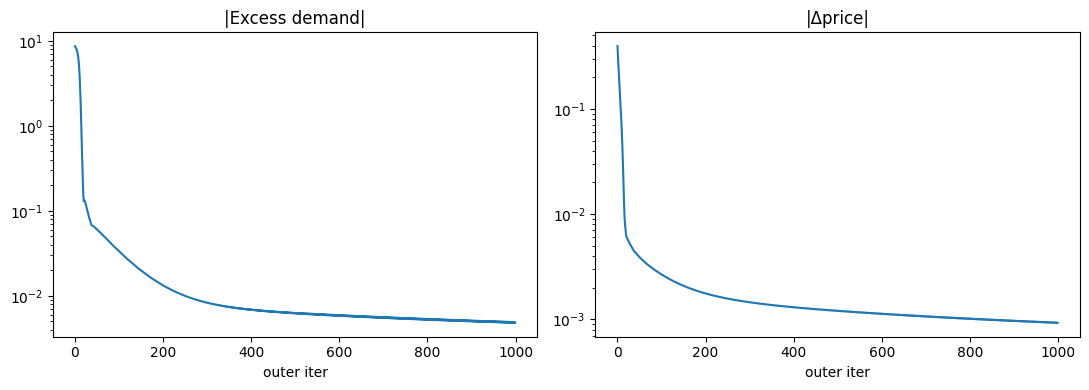


Final prices p (S, I):
[[1.1184 1.0825]
 [1.1321 1.1682]]
Final wages w  : [0.6118 0.6151]
Final rents r  : [0.0773 0.0825]
Final beta     : 2.26597423510124
Final gamma    : [0.0122 0.013 ]
Final I_infra  : [0.9732 1.0314]
Final Q_ship   :
[[[0.     0.    ]
  [0.1624 0.    ]]

 [[0.     0.1014]
  [0.     0.    ]]]
Final q_pop    :
[[[0.328  0.1753]
  [0.1741 0.3261]]

 [[0.3282 0.1748]
  [0.1714 0.3221]]]

Final excess demand:
  goods: [[ 0. -0.]
 [ 0. -0.]]
  time : [-0. -0.]
  land : [ 0.0001 -0.0001]
  infra: 0.0046089614817907965


In [158]:
hist_ed  = solver.logger.history['excess_demand']
hist_dp  = solver.logger.history['price_changes']

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(hist_ed);  ax[0].set_title('|Excess demand|'); ax[0].set_xlabel('outer iter')
ax[1].semilogy(hist_dp);  ax[1].set_title('|Δprice|');         ax[1].set_xlabel('outer iter')
plt.tight_layout(); plt.show()

print("\nFinal prices p (S, I):"); print(final_state.p)
print("Final wages w  :", final_state.w)
print("Final rents r  :", final_state.r)
print("Final beta     :", final_state.beta)
print("Final gamma    :", final_state.gamma)
print("Final I_infra  :", final_state.I_infra)
print("Final Q_ship   :"); print(final_state.Q_ship)
print("Final q_pop    :"); print(final_state.q_pop)
print("\nFinal excess demand:")
print("  goods:", ed.ED_goods)
print("  time :", ed.ED_time)
print("  land :", ed.ED_land)
print("  infra:", ed.ED_infra)

In [159]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import networkx as nx
from typing import Optional

class EquilibriumVisualizer:
    """
    Universal visualizer for the spatial GE model.
    Works for any (S, I, network) configuration.
    Requires only final_state, params, ed, and optionally:
      - zone_pos:  dict {zone_id: (x, y)}  for spatial layout
      - zone_names: list[str]
      - sector_names: list[str]
    """

    def __init__(
        self,
        final_state: ModelState,
        params:      ModelParams,
        ed:          ExcessDemand,
        solver:      UrbanModelSolver,
        zone_pos:    Optional[dict] = None,
        zone_names:  Optional[list] = None,
        sector_names:Optional[list] = None,
    ):
        self.state   = final_state
        self.params  = params
        self.ed      = ed
        self.solver  = solver
        self.S       = params.n_sectors
        self.I       = params.n_zones
        self.net     = params.network

        # ---- labels ----
        self.sector_names = sector_names or [f'S{s}' for s in range(self.S)]
        self.zone_names   = zone_names   or [f'Z{i}' for i in range(self.I)]

        # ---- spatial layout ----
        if zone_pos is not None:
            self.zone_pos = zone_pos
        else:
            self.zone_pos = self._auto_layout()

        # ---- build networkx graph for drawing ----
        self.G = self._build_nx_graph()

    # ================================================================
    # Layout helpers
    # ================================================================

    def _auto_layout(self) -> dict:
        """
        Automatic layout:
          - If zones sit on a square grid  -> grid layout
          - Otherwise                      -> spring layout via networkx
        """
        I = self.I
        side = int(np.round(np.sqrt(I)))
        if side * side == I:
            # perfect square grid
            return {i: (i % side, -(i // side)) for i in range(I)}
        else:
            # spring layout on the zone-level graph
            G = nx.DiGraph()
            G.add_nodes_from(range(I))
            for a, b in self.net.edges:
                za = np.where(self.net.zone_to_node == a)[0]
                zb = np.where(self.net.zone_to_node == b)[0]
                if len(za) and len(zb):
                    G.add_edge(za[0], zb[0])
            pos = nx.spring_layout(G, seed=0)
            return {i: pos[i] for i in range(I)}

    def _build_nx_graph(self) -> nx.DiGraph:
        G = nx.DiGraph()
        for i in range(self.I):
            G.add_node(i, pos=self.zone_pos[i])
        # one directed edge per (zone_i, zone_j) pair reachable in network
        node_to_zone = {n: z for z, n in enumerate(self.net.zone_to_node)}
        for a, b in self.net.edges:
            za = node_to_zone.get(a)
            zb = node_to_zone.get(b)
            if za is not None and zb is not None and za != zb:
                if not G.has_edge(za, zb):
                    G.add_edge(za, zb)
        return G

    # ================================================================
    # 1. Convergence
    # ================================================================

    def plot_convergence(self, figsize=(12, 4)):
        hist_ed = self.solver.logger.history['excess_demand']
        hist_dp = self.solver.logger.history['price_changes']

        fig, axes = plt.subplots(1, 2, figsize=figsize)
        axes[0].semilogy(hist_ed, color='steelblue', lw=1.5)
        axes[0].set_title('|Excess demand|  (outer loop)')
        axes[0].set_xlabel('outer iteration')
        axes[0].set_ylabel('ℓ² norm')
        axes[0].grid(True, which='both', ls='--', alpha=0.4)

        axes[1].semilogy(hist_dp, color='darkorange', lw=1.5)
        axes[1].set_title('|Δprice|  (outer loop)')
        axes[1].set_xlabel('outer iteration')
        axes[1].set_ylabel('ℓ² norm')
        axes[1].grid(True, which='both', ls='--', alpha=0.4)

        plt.suptitle('Tâtonnement convergence', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ================================================================
    # 2. Spatial maps (prices, rents, output, population)
    # ================================================================

    def _draw_network_base(self, ax, node_values, node_cmap, node_label,
                           edge_values=None, edge_cmap='Greys',
                           vmin=None, vmax=None):
        """
        Draw the zone graph with nodes colored by node_values (shape I,)
        and optionally edges colored by edge_values (shape I x I or n_edges).
        Returns the node ScalarMappable for colorbar.
        """
        pos = self.zone_pos
        vmin = vmin or node_values.min()
        vmax = vmax or node_values.max()
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap(node_cmap)
        node_colors = [cmap(norm(node_values[i])) for i in range(self.I)]

        # edges
        nx.draw_networkx_edges(
            self.G, pos, ax=ax,
            edge_color='lightgrey', arrows=False,
            width=1.2, alpha=0.6,
        )
        # nodes
        nx.draw_networkx_nodes(
            self.G, pos, ax=ax,
            node_color=node_colors,
            node_size=600, linewidths=1.0, edgecolors='grey',
        )
        # labels
        nx.draw_networkx_labels(
            self.G, pos, ax=ax,
            labels={i: f'{self.zone_names[i]}\n{node_values[i]:.2f}'
                    for i in range(self.I)},
            font_size=6, font_color='white',
        )
        ax.set_title(node_label, fontsize=9)
        ax.axis('off')
        return ScalarMappable(norm=norm, cmap=cmap)

    def plot_spatial_maps(self, figsize_per_panel=(3.2, 2.8)):
        """
        Grid of spatial maps:
          Row 0: prices p[s, :] for each sector
          Row 1: output Y[s, :] for each sector
          Row 2: rents r[:], residential pop, workplace pop
        """
        S, I = self.S, self.I
        n_cols = max(S, 3)
        n_rows = 3
        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(figsize_per_panel[0] * n_cols,
                     figsize_per_panel[1] * n_rows)
        )
        # ensure 2-d axes array
        if n_rows == 1: axes = axes[np.newaxis, :]
        if n_cols == 1: axes = axes[:, np.newaxis]

        # ---- row 0: prices ----
        p_all = self.state.p          # (S, I)
        p_min, p_max = p_all.min(), p_all.max()
        for s in range(S):
            sm = self._draw_network_base(
                axes[0, s], p_all[s], 'YlOrRd',
                f'Price  {self.sector_names[s]}',
                vmin=p_min, vmax=p_max,
            )
        for s in range(S, n_cols):
            axes[0, s].axis('off')
        fig.colorbar(sm, ax=axes[0, :S], shrink=0.6, label='price p')

        # ---- row 1: output ----
        Y_all = self.state.Y          # (S, I)
        Y_min, Y_max = Y_all.min(), Y_all.max()
        for s in range(S):
            sm = self._draw_network_base(
                axes[1, s], Y_all[s], 'Blues',
                f'Output Y  {self.sector_names[s]}',
                vmin=Y_min, vmax=Y_max,
            )
        for s in range(S, n_cols):
            axes[1, s].axis('off')
        fig.colorbar(sm, ax=axes[1, :S], shrink=0.6, label='output Y')

        # ---- row 2: rents + population ----
        sm = self._draw_network_base(
            axes[2, 0], self.state.r, 'RdPu', 'Land rent  r'
        )
        fig.colorbar(sm, ax=axes[2, 0], shrink=0.8)

        res_pop = self.state.q_pop.sum(axis=(0, 2))   # sum over s, j -> (I,)
        sm = self._draw_network_base(
            axes[2, 1], res_pop, 'Greens', 'Residential pop'
        )
        fig.colorbar(sm, ax=axes[2, 1], shrink=0.8)

        work_pop = self.state.q_pop.sum(axis=(0, 1))  # sum over s, i -> (I,)
        sm = self._draw_network_base(
            axes[2, 2], work_pop, 'Purples', 'Workplace pop'
        )
        fig.colorbar(sm, ax=axes[2, 2], shrink=0.8)

        for c in range(3, n_cols):
            axes[2, c].axis('off')

        plt.suptitle('Spatial equilibrium maps', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ================================================================
    # 3. Network flows (infrastructure + congestion + goods + commuters)
    # ================================================================

    def plot_network_flows(self, figsize=(14, 6)):
        """
        Four edge-level maps drawn on the zone graph:
          I_infra, gamma (congestion toll), goods flow, commuter flow.
        Edge width encodes magnitude; color encodes direction (asymmetry).
        """
        net   = self.net
        state = self.state

        # Build zone-level aggregates for each directed zone pair (i, j)
        node_to_zone = {n: z for z, n in enumerate(net.zone_to_node)}

        def edge_zone_map(arr_edge):
            """Map edge-level array (n_edges,) to zone-pair dict {(i,j): val}."""
            d = {}
            for e, (a, b) in enumerate(net.edges):
                za, zb = node_to_zone.get(a), node_to_zone.get(b)
                if za is not None and zb is not None and za != zb:
                    d[(za, zb)] = d.get((za, zb), 0.0) + arr_edge[e]
            return d

        I_map     = edge_zone_map(state.I_infra)
        gamma_map = edge_zone_map(state.gamma)
        goods_map = edge_zone_map(state.Q_hat_s_goods.sum(axis=0))
        comm_map  = edge_zone_map(state.q_hat_s.sum(axis=0))

        fig, axes = plt.subplots(1, 4, figsize=figsize)
        titles  = ['Infrastructure  I', 'Congestion  γ',
                   'Goods flow  ΣQ̂_goods', 'Commuter flow  Σq̂']
        maps    = [I_map, gamma_map, goods_map, comm_map]
        cmaps   = ['Blues', 'Reds', 'Oranges', 'Greens']
        pos     = self.zone_pos

        for ax, title, fmap, cm in zip(axes, titles, maps, cmaps):
            if not fmap:
                ax.axis('off'); ax.set_title(title); continue

            vals   = np.array(list(fmap.values()))
            vmin, vmax = vals.min(), vals.max()
            if vmax == vmin: vmax = vmin + 1e-9
            norm   = mcolors.Normalize(vmin=vmin, vmax=vmax)
            cmap   = plt.get_cmap(cm)

            # draw nodes
            nx.draw_networkx_nodes(
                self.G, pos, ax=ax,
                node_color='lightgrey', node_size=400,
                edgecolors='grey', linewidths=0.8,
            )
            nx.draw_networkx_labels(
                self.G, pos, ax=ax,
                labels={i: self.zone_names[i] for i in range(self.I)},
                font_size=7,
            )

            # draw each directed edge individually
            for (za, zb), val in fmap.items():
                color = cmap(norm(val))
                width = 1.0 + 5.0 * (val - vmin) / (vmax - vmin + 1e-12)
                nx.draw_networkx_edges(
                    self.G, pos, ax=ax,
                    edgelist=[(za, zb)],
                    edge_color=[color],
                    width=width,
                    arrows=True,
                    arrowsize=12,
                    connectionstyle='arc3,rad=0.15',
                )

            sm = ScalarMappable(norm=norm, cmap=cmap)
            fig.colorbar(sm, ax=ax, shrink=0.7)
            ax.set_title(title, fontsize=9)
            ax.axis('off')

        plt.suptitle('Network flows at equilibrium', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ================================================================
    # 4. Trade matrix (heatmap per sector)
    # ================================================================

    def plot_trade_matrices(self, figsize_per_panel=(3.0, 2.5)):
        S, I = self.S, self.I
        fig, axes = plt.subplots(
            1, S,
            figsize=(figsize_per_panel[0] * S, figsize_per_panel[1])
        )
        if S == 1: axes = [axes]

        Q = self.state.Q_ship   # (S, I, I)
        vmax = Q.max()

        for s, ax in enumerate(axes):
            im = ax.imshow(Q[s], cmap='YlOrRd', vmin=0, vmax=vmax, origin='upper')
            ax.set_title(f'Q_ship  {self.sector_names[s]}', fontsize=9)
            ax.set_xticks(range(I)); ax.set_xticklabels(self.zone_names, fontsize=6, rotation=45)
            ax.set_yticks(range(I)); ax.set_yticklabels(self.zone_names, fontsize=6)
            ax.set_xlabel('destination', fontsize=7)
            ax.set_ylabel('origin', fontsize=7)
            for i in range(I):
                for j in range(I):
                    ax.text(j, i, f'{Q[s,i,j]:.2f}',
                            ha='center', va='center', fontsize=6,
                            color='black' if Q[s,i,j] < 0.6*vmax else 'white')
            fig.colorbar(im, ax=ax, shrink=0.8)

        plt.suptitle('Trade flows  Q_ship[s, origin, destination]',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ================================================================
    # 5. Commuting matrix
    # ================================================================

    def plot_commuting_matrix(self, figsize=(5, 4)):
        commute = self.state.q_pop.sum(axis=0)   # (I, I)
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(commute, cmap='viridis', origin='upper')
        ax.set_title('Commuting matrix  Σ_s q_pop[s, i, j]', fontsize=10)
        ax.set_xticks(range(self.I))
        ax.set_xticklabels(self.zone_names, fontsize=7, rotation=45)
        ax.set_yticks(range(self.I))
        ax.set_yticklabels(self.zone_names, fontsize=7)
        ax.set_xlabel('workplace  j', fontsize=8)
        ax.set_ylabel('residence  i', fontsize=8)
        for i in range(self.I):
            for j in range(self.I):
                ax.text(j, i, f'{commute[i,j]:.3f}',
                        ha='center', va='center', fontsize=6,
                        color='white' if commute[i,j] > 0.5 * commute.max() else 'black')
        fig.colorbar(im, ax=ax, shrink=0.9, label='population flow')
        plt.tight_layout()
        plt.show()

    # ================================================================
    # 6. Prices + wages + rents bar charts
    # ================================================================

    def plot_prices_wages_rents(self, figsize=(13, 4)):
        fig, axes = plt.subplots(1, 3, figsize=figsize)

        # prices: grouped bar (sector × zone)
        x = np.arange(self.I)
        width = 0.8 / self.S
        for s in range(self.S):
            axes[0].bar(x + s * width, self.state.p[s],
                        width=width, label=self.sector_names[s], alpha=0.85)
        axes[0].set_xticks(x + width * (self.S - 1) / 2)
        axes[0].set_xticklabels(self.zone_names, fontsize=8)
        axes[0].set_title('Goods prices  p[s, zone]')
        axes[0].set_ylabel('price')
        axes[0].legend(fontsize=7)
        axes[0].grid(axis='y', ls='--', alpha=0.4)

        # wages: simple bar over sectors
        axes[1].bar(self.sector_names, self.state.w,
                    color='steelblue', alpha=0.85)
        axes[1].set_title('Wages  w[sector]')
        axes[1].set_ylabel('wage')
        axes[1].grid(axis='y', ls='--', alpha=0.4)

        # rents: bar over zones
        axes[2].bar(self.zone_names, self.state.r,
                    color='coral', alpha=0.85)
        axes[2].set_title('Land rents  r[zone]')
        axes[2].set_ylabel('rent')
        axes[2].tick_params(axis='x', labelsize=7)
        axes[2].grid(axis='y', ls='--', alpha=0.4)

        plt.suptitle('Prices, wages and rents at equilibrium',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ================================================================
    # 7. Excess demand summary
    # ================================================================

    def plot_excess_demand(self, figsize=(13, 3)):
        fig, axes = plt.subplots(1, 4, figsize=figsize)

        # goods: heatmap (S x I)
        im = axes[0].imshow(self.ed.ED_goods, cmap='RdBu_r',
                            norm=mcolors.CenteredNorm())
        axes[0].set_title('ED goods  [s, zone]', fontsize=9)
        axes[0].set_yticks(range(self.S))
        axes[0].set_yticklabels(self.sector_names, fontsize=7)
        axes[0].set_xticks(range(self.I))
        axes[0].set_xticklabels(self.zone_names, fontsize=6, rotation=45)
        fig.colorbar(im, ax=axes[0], shrink=0.8)

        # time: bar over sectors
        axes[1].bar(self.sector_names, self.ed.ED_time,
                    color=['red' if v > 0 else 'blue' for v in self.ed.ED_time],
                    alpha=0.8)
        axes[1].axhline(0, color='k', lw=0.8)
        axes[1].set_title('ED time  [sector]', fontsize=9)
        axes[1].set_ylabel('excess demand')
        axes[1].grid(axis='y', ls='--', alpha=0.4)

        # land: bar over zones
        axes[2].bar(self.zone_names, self.ed.ED_land,
                    color=['red' if v > 0 else 'blue' for v in self.ed.ED_land],
                    alpha=0.8)
        axes[2].axhline(0, color='k', lw=0.8)
        axes[2].set_title('ED land  [zone]', fontsize=9)
        axes[2].tick_params(axis='x', labelsize=7)
        axes[2].grid(axis='y', ls='--', alpha=0.4)

        # infra: single value
        axes[3].bar(['infra'], [self.ed.ED_infra],
                    color='red' if self.ed.ED_infra > 0 else 'blue',
                    alpha=0.8)
        axes[3].axhline(0, color='k', lw=0.8)
        axes[3].set_title(f'ED infra  (β={self.state.beta:.3f})', fontsize=9)
        axes[3].grid(axis='y', ls='--', alpha=0.4)

        plt.suptitle('Excess demand at equilibrium  (≈ 0 ⟹ market clearing)',
                     fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # ================================================================
    # 8. Master dashboard — call everything
    # ================================================================

    def dashboard(self):
        print("=" * 60)
        print("  EQUILIBRIUM DASHBOARD")
        print("=" * 60)
        self.plot_convergence()
        self.plot_prices_wages_rents()
        self.plot_spatial_maps()
        self.plot_network_flows()
        self.plot_trade_matrices()
        self.plot_commuting_matrix()
        self.plot_excess_demand()
        self._print_summary()

    def _print_summary(self):
        state, ed = self.state, self.ed
        print("\n── Equilibrium summary ──────────────────────────────")
        print(f"  Sectors  : {self.sector_names}")
        print(f"  Zones    : {self.zone_names}")
        print(f"  Wages    : {np.round(state.w, 4)}")
        print(f"  Rents    : {np.round(state.r, 4)}")
        print(f"  β (infra): {state.beta:.4f}")
        print(f"  Σκ·I     : {(self.net.kappa * state.I_infra).sum():.4f}  "
              f"(budget K = {self.params.K})")
        off = 1 - sum(state.q_pop[s].diagonal().sum()
                      for s in range(self.S)) / state.q_pop.sum()
        print(f"  Off-diag commuting: {100*off:.1f}%")
        print(f"  max |ED| goods : {np.abs(ed.ED_goods).max():.2e}")
        print(f"  max |ED| time  : {np.abs(ed.ED_time).max():.2e}")
        print(f"  max |ED| land  : {np.abs(ed.ED_land).max():.2e}")
        print(f"  |ED| infra     : {abs(ed.ED_infra):.2e}")
        print("─" * 52)

  EQUILIBRIUM DASHBOARD


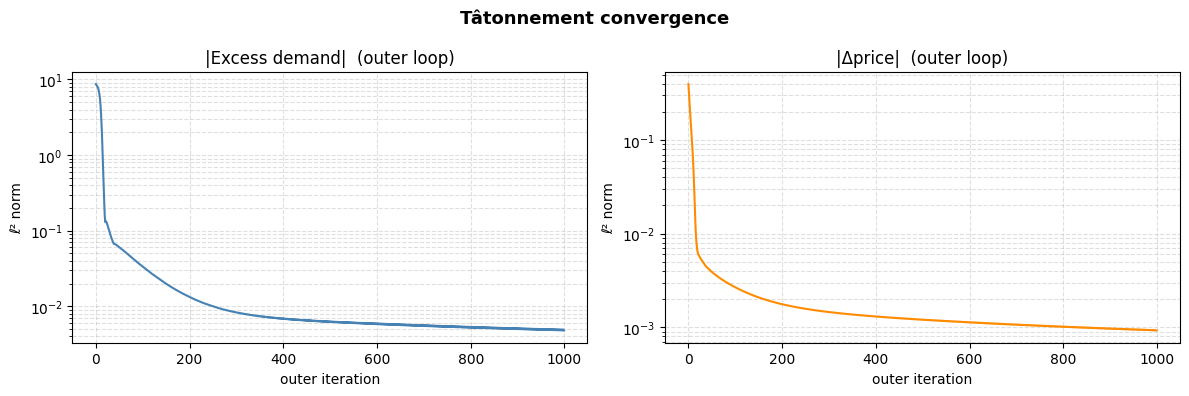

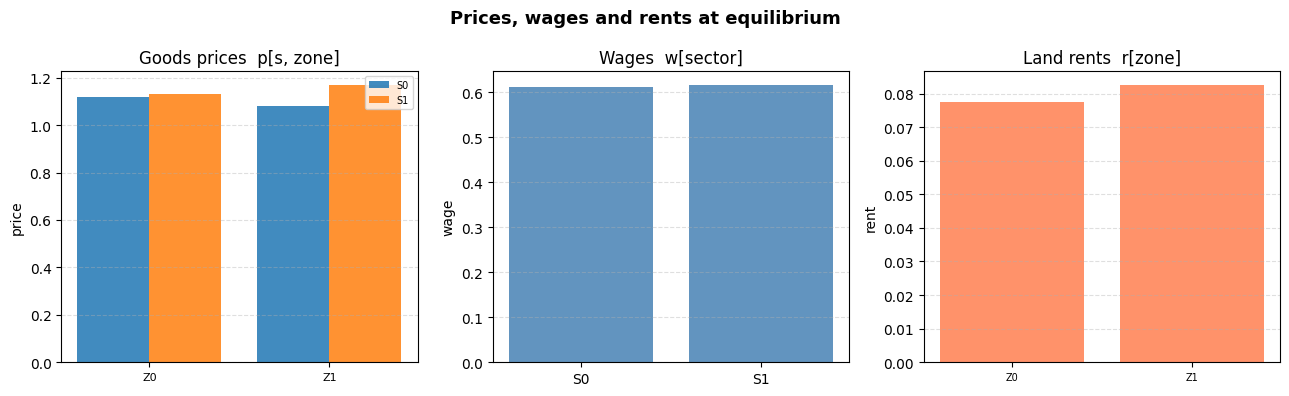

/tmp/ipykernel_1220875/1517500629.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


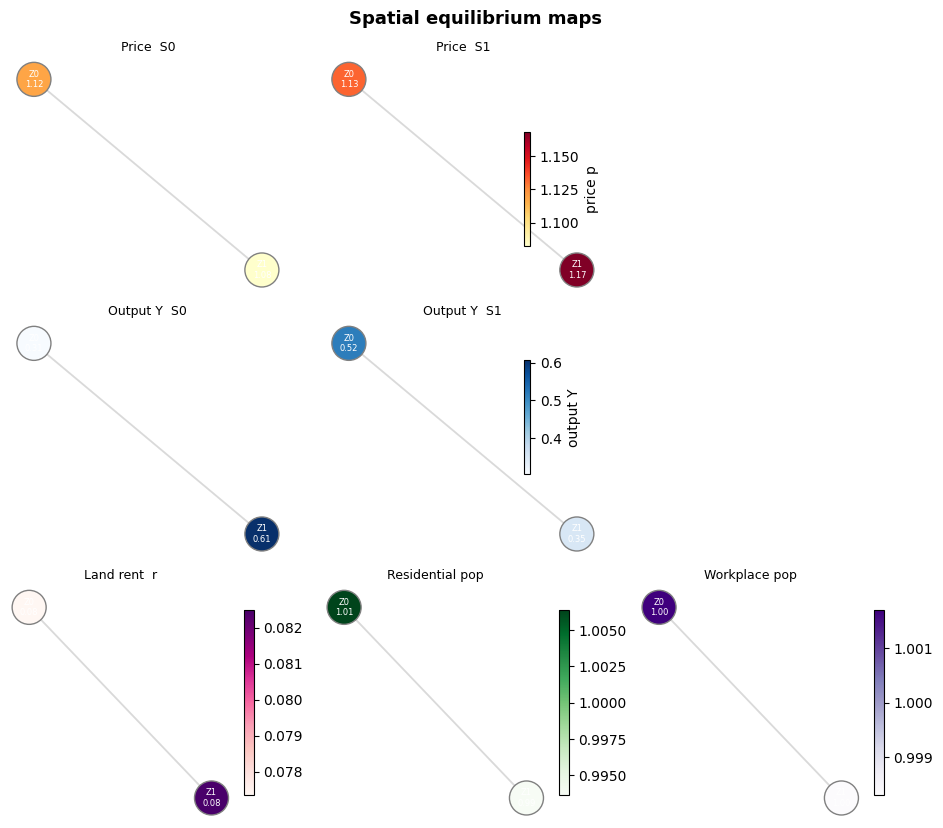

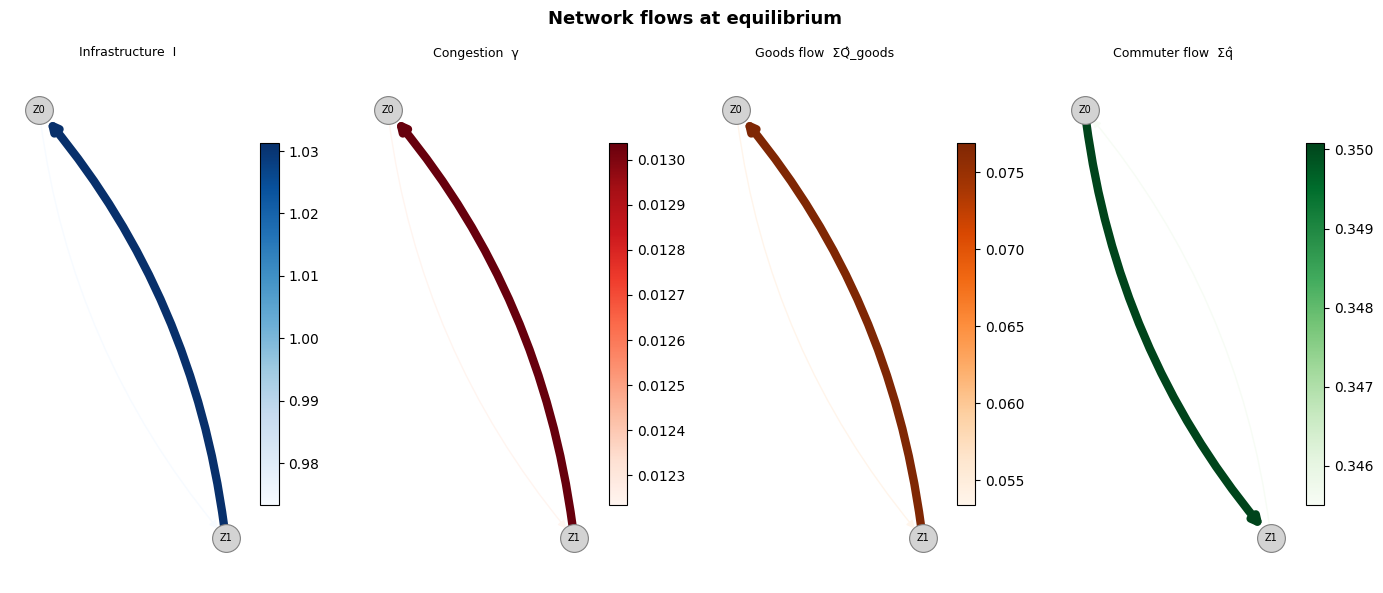

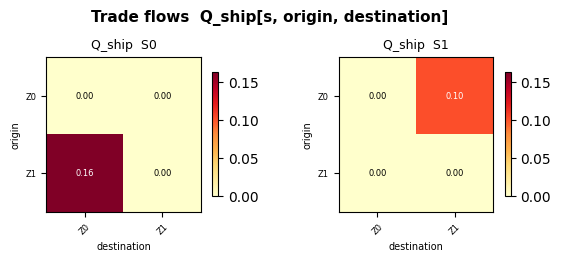

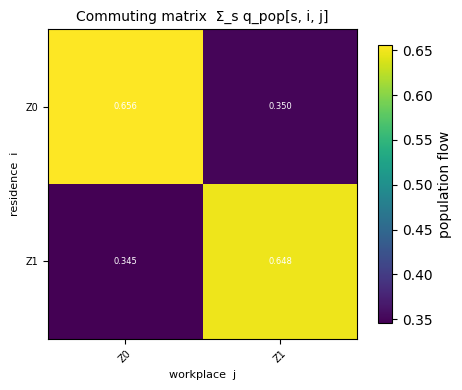

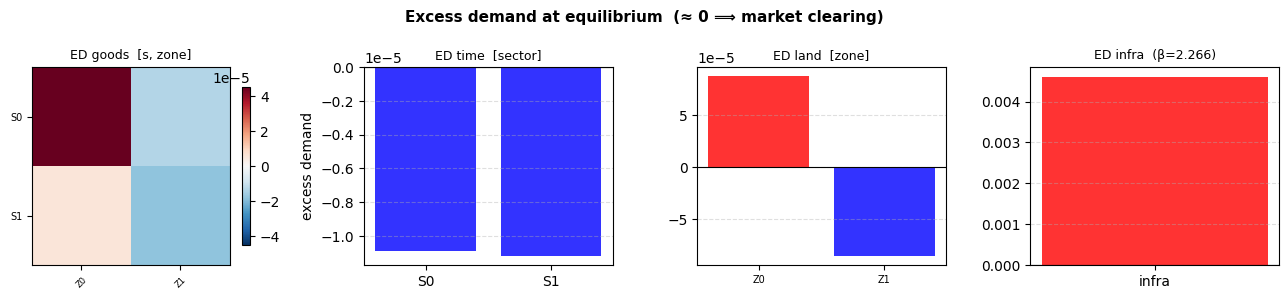


── Equilibrium summary ──────────────────────────────
  Sectors  : ['S0', 'S1']
  Zones    : ['Z0', 'Z1']
  Wages    : [0.6118 0.6151]
  Rents    : [0.0773 0.0825]
  β (infra): 2.2660
  Σκ·I     : 2.0046  (budget K = 2.0)
  Off-diag commuting: 34.8%
  max |ED| goods : 4.51e-05
  max |ED| time  : 1.12e-05
  max |ED| land  : 8.77e-05
  |ED| infra     : 4.61e-03
────────────────────────────────────────────────────


In [160]:
# Minimal (auto layout, auto labels)
viz = EquilibriumVisualizer(final_state, params, ed, solver)
viz.dashboard()

## Intermediate example

In [161]:
class QuadraticProduction(ProductionFunction):
    """
    Y = A_s_j * (alpha_H H + alpha_L L + alpha_Q.Q) - 0.5 * (beta_H H^2 + beta_L L^2 + beta_Q.Q^2)
    """
    def __init__(self, A, alpha_H, alpha_L, alpha_Q, beta_H, beta_L, beta_Q):
        self.A       = np.asarray(A, dtype=float)             # (S, J)
        self.alpha_H = np.asarray(alpha_H, dtype=float)       # (S,)
        self.alpha_L = np.asarray(alpha_L, dtype=float)       # (S,)
        self.alpha_Q = np.asarray(alpha_Q, dtype=float)       # (S, S)
        self.beta_H  = np.asarray(beta_H, dtype=float)        # (S,)
        self.beta_L  = np.asarray(beta_L, dtype=float)        # (S,)
        self.beta_Q  = np.asarray(beta_Q, dtype=float)        # (S, S)

    def __call__(self, H, L, Q_inp, s, j):
        Q = np.asarray(Q_inp)
        lin  = self.alpha_H[s]*H + self.alpha_L[s]*L + (self.alpha_Q[s]*Q).sum()
        quad = self.beta_H[s]*H**2 + self.beta_L[s]*L**2 + (self.beta_Q[s]*Q**2).sum()
        return float(self.A[s, j] * lin - 0.5 * quad)

    def gradient(self, H, L, Q_inp, s, j, var=None):
        Q = np.asarray(Q_inp); A = self.A[s, j]
        if var == 'H': return A*self.alpha_H[s] - self.beta_H[s]*H
        if var == 'L': return A*self.alpha_L[s] - self.beta_L[s]*L
        if var == 'Q': return A*self.alpha_Q[s]  - self.beta_Q[s]*Q
        return None

    def invert(self, p_sj, p_vec, w_s, r_j, s, j, H_sj=None):
        A = self.A[s, j]
        # FOC: p * (A*alpha - beta*x) = price_x  =>  x = (A*alpha - price_x/p) / beta
        H = max(0.0, (A*self.alpha_H[s] - w_s/p_sj) / self.beta_H[s])
        L = max(0.0, (A*self.alpha_L[s] - r_j/p_sj) / self.beta_L[s])
        Q_inp = np.maximum(0.0, (A*self.alpha_Q[s] - p_vec/p_sj) / self.beta_Q[s])
        Y = self(H, L, Q_inp, s, j)
        return Y, H, L, Q_inp

In [162]:
np.random.seed(42)

# ---- dimensions ----
S = 3                   # sectors: 0=agriculture, 1=manufacturing, 2=services
I_zones = 4             # zones
n_nodes = 9             # 5 zone-nodes + 4 routing nodes

# ---- network: zones 0..4 sit at nodes 0..4, hub at node 5, routing at 6,7,8 ----
# topology:
#   0 -- 5 -- 1     (corridor west-east through hub 5)
#   2 -- 5            (zone 2 connects to hub)
#   3 -- 6 -- 5     (zone 3 reached via routing node 6)
#   4 -- 7 -- 5     (zone 4 reached via routing node 7)
#   plus a long detour: 0 -- 8 -- 1 (slower alternate)
edge_list = [
    (0, 5), (5, 0),
    (1, 5), (5, 1),
    (2, 5), (5, 2),
    (3, 6), (6, 3),
    (5, 6), (6, 5),
    (4, 7), (7, 4),
    (5, 7), (7, 5),
    (0, 8), (8, 0),
    (1, 8), (8, 1),
]
n_edges = len(edge_list)

# baseline free-flow times (longer for the detour)
T0 = np.ones(n_edges)
T0[-4:] = 3.0           # the (0,8),(8,0),(1,8),(8,1) detour links are slow

# infrastructure cost: hub-adjacent links are expensive
kappa = np.ones(n_edges)
for k, (a, b) in enumerate(edge_list):
    if 5 in (a, b):     # hub edges cost more to upgrade
        kappa[k] = 2.0

I_min = np.full(n_edges, 0.1)
I_max = np.full(n_edges, 5.0)

network = Network(
    n_nodes=n_nodes,
    edges=edge_list,
    kappa=kappa,
    I_min=I_min,
    I_max=I_max,
    zone_to_node=np.array([0, 1, 2, 3, 4]),
)

In [163]:
# ---- utility: each sector's HHs prefer their own good slightly more ----
# sectors are: 0=agri-workers, 1=manuf-workers, 2=service-workers
util = CobbDouglasUtility(
    alpha_c=np.array([
        [0.3, 0.2, 0.3],     # sector-0 HHs
        [0.2, 0.3, 0.3],     # sector-1 HHs
        [0.2, 0.2, 0.4],     # sector-2 HHs
    ]),
    alpha_l=np.array([0.2, 0.2, 0.2]),
    alpha_f=np.array([0.3, 0.3, 0.3])
)

# ---- production: comparative advantage by zone ----
# zone 0: agriculture (rural west)
# zone 1: manufacturing (industrial east)
# zone 2: services (south, near hub)
# zone 3: agriculture (remote)
A = np.array([
    #  z0   z1   z2   z3
    [1.5, 0.8, 0.9, 1.4],   # sector 0 (agri)
    [0.7, 1.6, 1.0, 0.6],   # sector 1 (manuf)
    [0.9, 1.0, 1.4, 0.7],   # sector 2 (services)
])

prod = QuadraticProduction(
    A=A,
    alpha_H=np.array([2.0, 2.0, 2.0]),   # was 1.0
    alpha_L=np.array([1.5, 1.0, 0.8]),   # was 0.5/0.3/0.2
    alpha_Q=np.array([
        [0.0, 1.0, 1.0],                 # was 0.3
        [1.2, 0.0, 1.2],
        [1.0, 1.2, 0.0],
    ]),
    beta_H=np.array([1.0, 1.0, 1.0]),
    beta_L=np.array([1.0, 1.0, 1.0]),
    beta_Q=np.ones((3, 3)),
)

# ---- transport: services slightly more perishable (higher iceberg loss) ----
tau_fn  = IcebergTau(delta=np.array([0.05, 0.04, 0.08]))
time_fn = BPRTime(T0=T0, a=0.15, b=4.0)

# ---- endowments ----
L_bar = np.array([3.0, 2.0, 2.5, 4.0])   # rural zones have more land

params = ModelParams(
    n_zones=I_zones, n_sectors=S,
    production_function=prod,
    utility_function=util,
    L_bar=L_bar,
    H_bar=1.0,
    q_bar=10.0,                  # ten "units" of population
    K=10,                       # tight infra budget
    tau_link=tau_fn,
    t_link=time_fn,
    d_w=100,
    phi=np.array([1.0, 1.5, 0.5]),       # manuf is heavy, services light
    sigma=np.array([40, 80, 20]),
    sigma_tilde=100,                      # cross-sector mobility
    network=network,
)

hyperparams = AlgoParams(
    T_outer=3000, T_inner=30,             # short inner loop, MSA-style
    eta_p=0.05, eta_w=0.05, eta_r=0.05, eta_beta=0.05, eta_I=0.02,
    alpha_Q=0.3, alpha_Qhat=0.30, eta_gamma=0.05,
    tol_outer=1e-5, tol_inner=1e-3,
    verbose=True, log_every=10, decay_start=500, decay_type=None
)


# ---- soft budget penalty ----
params.lambda_K = 10.0

In [164]:
def make_initial_state(params) -> ModelState:
    S, I = params.n_sectors, params.n_zones
    E    = params.network.n_edges
    return ModelState(
        p   =np.ones((S, I)),
        w   =np.ones(S),
        r   =np.ones(I),
        beta=0.0,
        gamma=np.zeros(E),
        Y     =np.zeros((S, I)),
        H_prod=np.zeros((S, I)),
        L_prod=np.zeros((S, I)),
        Q_inter=np.zeros((S, S, I)),
        c     =np.zeros((S, S, I, I)),
        l_res =np.zeros((S, I, I)),
        f    =np.zeros((S, I, I)),
        Q_ship =np.zeros((S, I, I)),
        Q_tilde=np.zeros((S, I, I)),
        tau_eff=np.ones((S, I, I)),
        active =np.zeros((S, I, I), dtype=bool),
        q_pop  =np.full((S, I, I), params.q_bar / (S * I * I)),
        q_bar_s=np.full(S, params.q_bar / S),
        Q_hat              =np.full(E, 0.1),
        q_hat_s            =np.zeros((S, E)),
        Q_hat_s_goods      =np.zeros((S, E)),
        Q_hat_s_price_goods=np.zeros((S, E)),
        I_infra=np.full(E, 1.0),
        gamma_I=np.zeros(E),
    )

state0 = make_initial_state(params)

In [165]:
ed = ExcessDemand()
pu = PriceUpdater(ed)
solver = UrbanModelSolver(
    HouseholdBlock(), ProductionBlock(), TransportBlock(),
    InfrastructureBlock(), ed, pu,
)
final_state = solver.solve(state0, params, hyperparams)

[outer    0] |ED|=1.4989e+02  |Δprice|=3.3387e+02
[outer   10] |ED|=3.1880e+01  |Δprice|=6.4083e-01
[outer   20] |ED|=2.2046e+01  |Δprice|=6.7021e-01
[outer   30] |ED|=9.4973e+00  |Δprice|=4.7007e-01
[outer   40] |ED|=9.3694e+00  |Δprice|=4.6592e-01
[outer   50] |ED|=9.2776e+00  |Δprice|=4.6236e-01
[outer   60] |ED|=9.2274e+00  |Δprice|=4.6013e-01
[outer   70] |ED|=9.2052e+00  |Δprice|=4.5914e-01
[outer   80] |ED|=9.1600e+00  |Δprice|=4.5688e-01
[outer   90] |ED|=9.1261e+00  |Δprice|=4.5508e-01
[outer  100] |ED|=9.0805e+00  |Δprice|=4.5285e-01
[outer  110] |ED|=9.0499e+00  |Δprice|=4.5131e-01
[outer  120] |ED|=9.0173e+00  |Δprice|=4.4957e-01
[outer  130] |ED|=8.9701e+00  |Δprice|=4.4716e-01
[outer  140] |ED|=8.9383e+00  |Δprice|=4.4547e-01
[outer  150] |ED|=8.8923e+00  |Δprice|=4.4314e-01
[outer  160] |ED|=8.8427e+00  |Δprice|=4.4071e-01
[outer  170] |ED|=8.7977e+00  |Δprice|=4.3837e-01
[outer  180] |ED|=8.7390e+00  |Δprice|=4.3550e-01
[outer  190] |ED|=8.6955e+00  |Δprice|=4.3318e-01


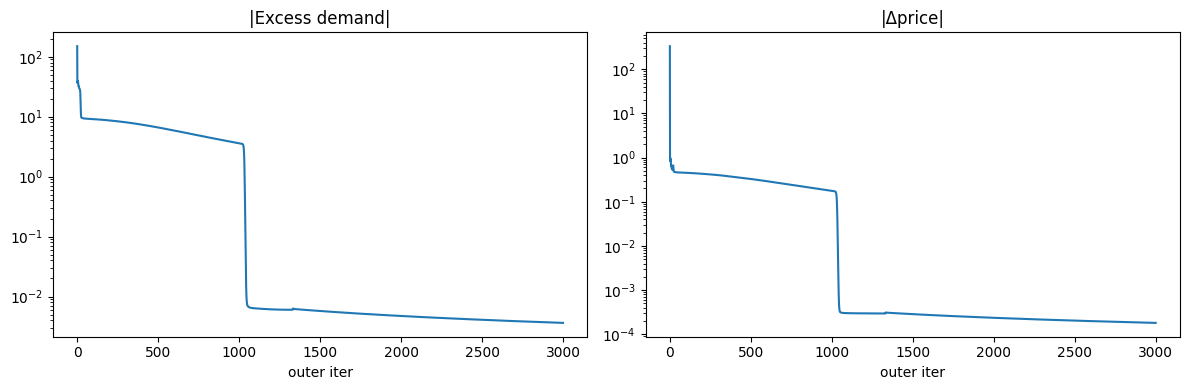


=== Prices p (sector × zone) ===
[[0.458 0.46  0.462 0.459]
 [0.595 0.594 0.597 0.599]
 [0.571 0.571 0.566 0.571]]

=== Output Y ===
[[3.952 0.18  0.541 2.935]
 [0.115 3.879 0.969 0.1  ]
 [0.914 1.47  4.904 0.166]]

=== Pop q_pop[s,i,j], summed over (i,j) ===
Pop by sector: [3.3536 3.4864 3.16  ]
Pop by residence i = [2.5023 2.4984 2.501  2.4982]
Pop by workplace j = [2.5023 2.4984 2.5011 2.4982]

=== Trade matrix (sector 0: agri shipments) ===
[[0.    2.432 0.076 0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    1.663 0.   ]]
=== Trade matrix (sector 1: manuf shipments) ===
[[0.    0.    0.    0.   ]
 [1.111 0.    0.643 0.976]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]]
=== Trade matrix (sector 2: services shipments) ===
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.797 0.945 0.    1.446]
 [0.    0.    0.    0.   ]]

=== Wages w ===: [1.1928 2.3108 0.7593]
=== Rents r ===: [0.3642 0.4781 0.3976 0.2399]
=== Infra budget: Σκ·I = 10.004, K

In [166]:
# convergence
hist_ed = solver.logger.history['excess_demand']
hist_dp = solver.logger.history['price_changes']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(hist_ed); ax[0].set_title('|Excess demand|'); ax[0].set_xlabel('outer iter')
ax[1].semilogy(hist_dp); ax[1].set_title('|Δprice|');         ax[1].set_xlabel('outer iter')
plt.tight_layout(); plt.show()

# economic structure
zones    = ['Z0(W-agri)', 'Z1(E-manuf)', 'Z2(S-srv)', 'Z3(remote)', 'Z4(N-srv)']
sectors  = ['agri', 'manuf', 'srv']

print("\n=== Prices p (sector × zone) ===")
print(np.array2string(final_state.p, precision=3))

print("\n=== Output Y ===");       print(np.array2string(final_state.Y, precision=3))
print("\n=== Pop q_pop[s,i,j], summed over (i,j) ===")
print("Pop by sector:", final_state.q_pop.sum(axis=(1,2)))
print("Pop by residence i =", final_state.q_pop.sum(axis=(0,2)))
print("Pop by workplace j =", final_state.q_pop.sum(axis=(0,1)))

print("\n=== Trade matrix (sector 0: agri shipments) ===")
print(np.array2string(final_state.Q_ship[0], precision=3))
print("=== Trade matrix (sector 1: manuf shipments) ===")
print(np.array2string(final_state.Q_ship[1], precision=3))
print("=== Trade matrix (sector 2: services shipments) ===")
print(np.array2string(final_state.Q_ship[2], precision=3))

print("\n=== Wages w ===:", final_state.w)
print("=== Rents r ===:", final_state.r)
print(f"=== Infra budget: Σκ·I = {(network.kappa * final_state.I_infra).sum():.3f}, K = {params.K}")
print("=== I_infra per edge ===")
for e, (a,b) in enumerate(edge_list):
    print(f"  edge ({a},{b}): I={final_state.I_infra[e]:.2f}, γ={final_state.gamma[e]:.3f}")

print("\n=== max |ED| per market ===")
print(f"  goods: {np.abs(ed.ED_goods).max():.2e}")
print(f"  time : {np.abs(ed.ED_time).max():.2e}")
print(f"  land : {np.abs(ed.ED_land).max():.2e}")
print(f"  infra: {abs(ed.ED_infra):.2e}")

  EQUILIBRIUM DASHBOARD


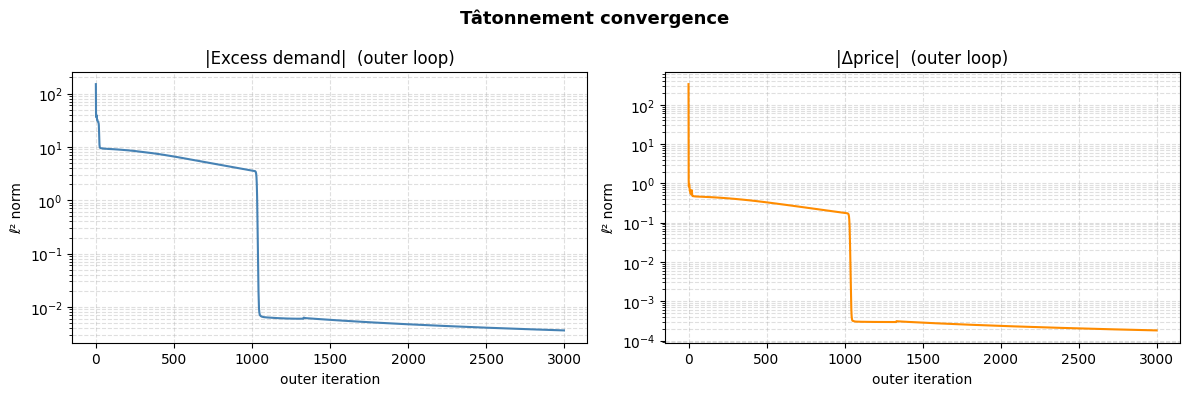

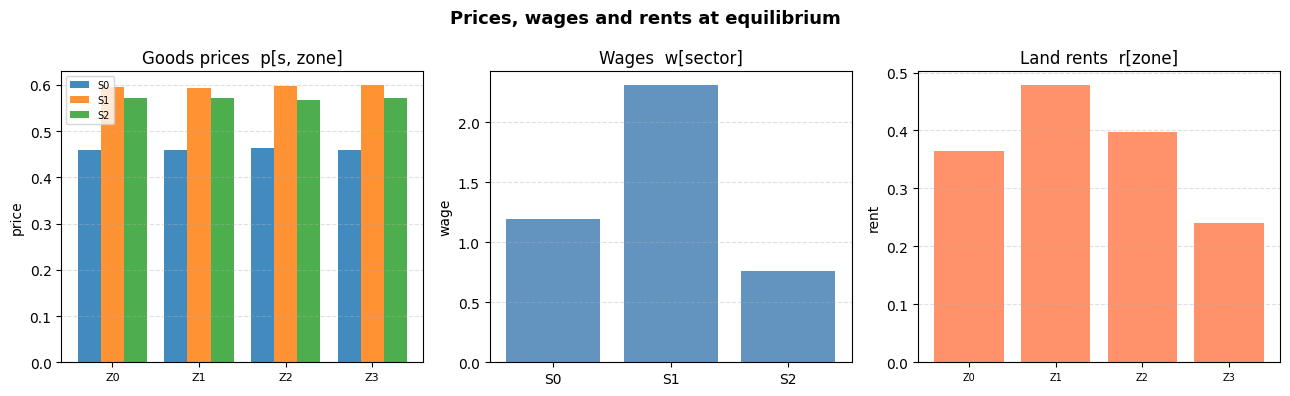

/tmp/ipykernel_1220875/1517500629.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


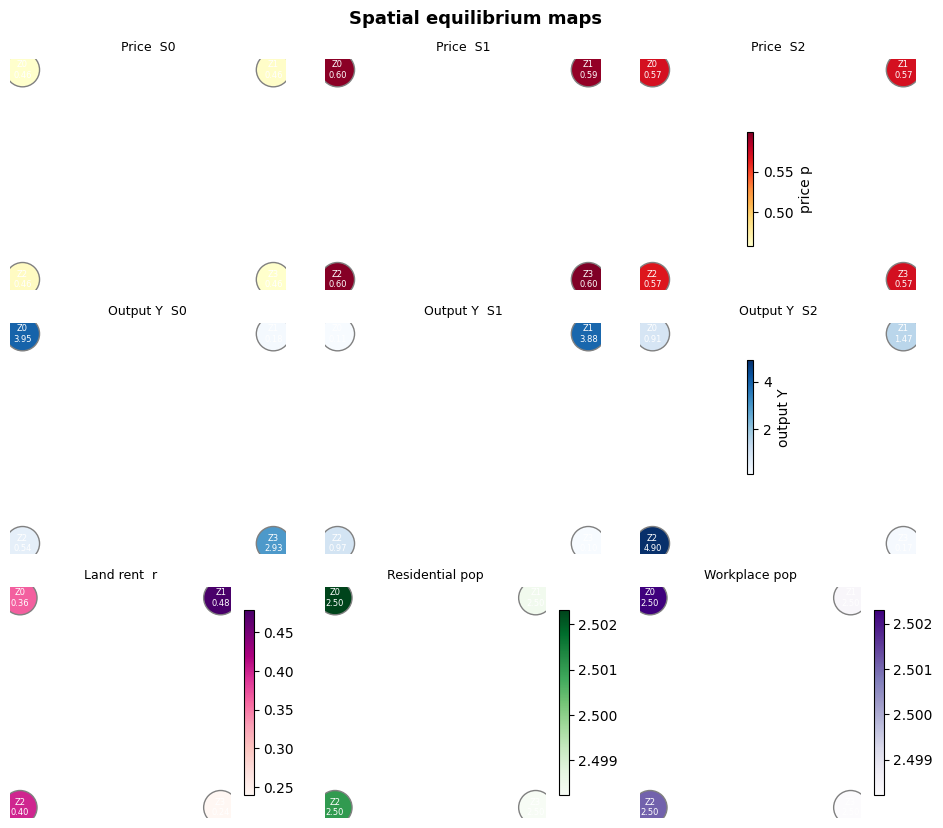

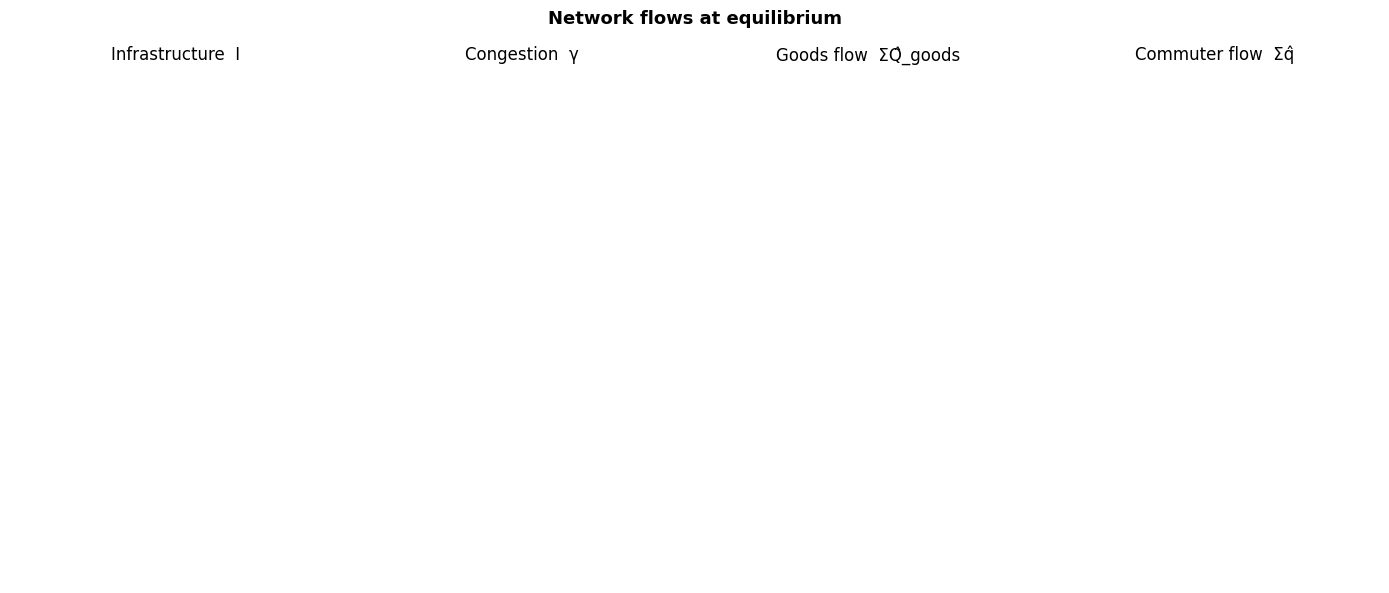

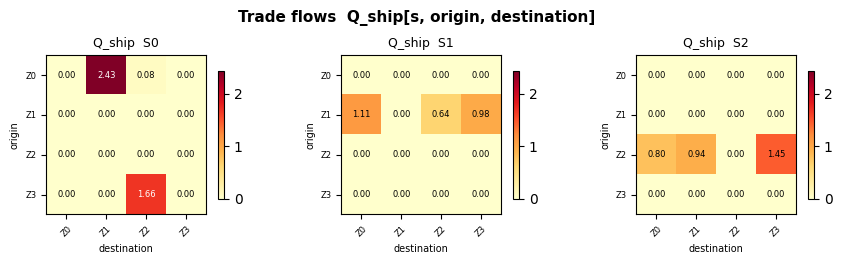

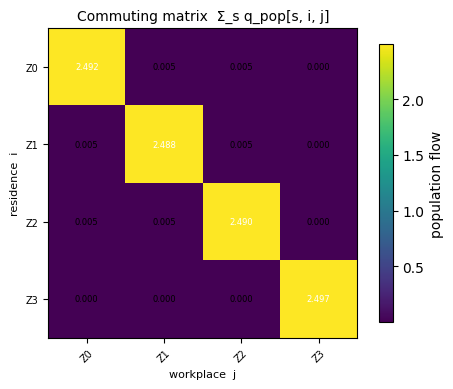

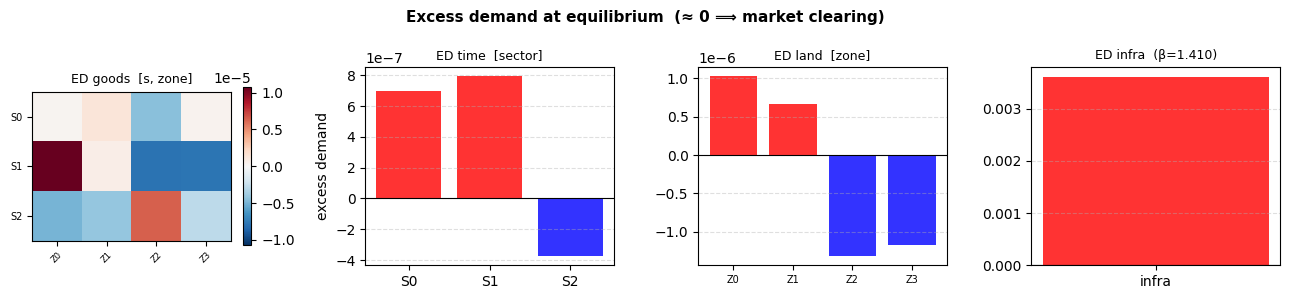


── Equilibrium summary ──────────────────────────────
  Sectors  : ['S0', 'S1', 'S2']
  Zones    : ['Z0', 'Z1', 'Z2', 'Z3']
  Wages    : [1.1928 2.3108 0.7593]
  Rents    : [0.3642 0.4781 0.3976 0.2399]
  β (infra): 1.4103
  Σκ·I     : 10.0036  (budget K = 10)
  Off-diag commuting: 0.3%
  max |ED| goods : 1.07e-05
  max |ED| time  : 7.93e-07
  max |ED| land  : 1.32e-06
  |ED| infra     : 3.61e-03
────────────────────────────────────────────────────


In [167]:
viz = EquilibriumVisualizer(final_state, params, ed, solver)
viz.dashboard()

In [168]:
# ---- utility: each sector's HHs prefer their own good slightly more ----
# sectors are: 0=agri-workers, 1=manuf-workers, 2=service-workers
util = CobbDouglasUtility(
    alpha_c=np.array([
        [0.3, 0.2, 0.3],     # sector-0 HHs
        [0.2, 0.3, 0.3],     # sector-1 HHs
        [0.2, 0.2, 0.4],     # sector-2 HHs
    ]),
    alpha_l=np.array([0.2, 0.2, 0.2]),
    alpha_f=np.array([0.3, 0.3, 0.3])
)

# ---- production: comparative advantage by zone ----
# zone 0: agriculture (rural west)
# zone 1: manufacturing (industrial east)
# zone 2: services (south, near hub)
# zone 3: agriculture (remote)
A = np.array([
    #  z0   z1   z2   z3
    [1.5, 0.8, 0.9, 1.4],   # sector 0 (agri)
    [0.7, 1.6, 1.0, 0.6],   # sector 1 (manuf)
    [0.9, 1.0, 1.4, 0.7],   # sector 2 (services)
])

prod = QuadraticProduction(
    A=A,
    alpha_H=np.array([2.0, 2.0, 2.0]),   # was 1.0
    alpha_L=np.array([1.5, 1.0, 0.8]),   # was 0.5/0.3/0.2
    alpha_Q=np.array([
        [0.0, 1.0, 1.0],                 # was 0.3
        [1.2, 0.0, 1.2],
        [1.0, 1.2, 0.0],
    ]),
    beta_H=np.array([1.0, 1.0, 1.0]),
    beta_L=np.array([1.0, 1.0, 1.0]),
    beta_Q=np.ones((3, 3)),
)

# ---- transport: services slightly more perishable (higher iceberg loss) ----
tau_fn  = IcebergTau(delta=np.array([0.05, 0.04, 0.08]))
time_fn = BPRTime(T0=T0, a=0.15, b=4.0)

# ---- endowments ----
L_bar = np.array([3.0, 2.0, 2.5, 4.0])   # rural zones have more land

params = ModelParams(
    n_zones=I_zones, n_sectors=S,
    production_function=prod,
    utility_function=util,
    L_bar=L_bar,
    H_bar=1.0,
    q_bar=10.0,                  # ten "units" of population
    K=10,                       # tight infra budget
    tau_link=tau_fn,
    t_link=time_fn,
    d_w=100,
    phi=np.array([1.0, 1.5, 0.5]),       # manuf is heavy, services light
    sigma=np.array([40, 80, 20]),
    sigma_tilde=100,                      # cross-sector mobility
    network=network,
)

hyperparams = AlgoParams(
    T_outer=1020, T_inner=30,             # short inner loop, MSA-style
    eta_p=0.05, eta_w=0.05, eta_r=0.05, eta_beta=0.05, eta_I=0.02,
    alpha_Q=0.3, alpha_Qhat=0.30, eta_gamma=0.05,
    tol_outer=1e-5, tol_inner=1e-3,
    verbose=True, log_every=10, decay_start=500, decay_type=None
)


# ---- soft budget penalty ----
params.lambda_K = 10.0

In [169]:
state0 = make_initial_state(params)
ed = ExcessDemand()
pu = PriceUpdater(ed)
solver = UrbanModelSolver(
    HouseholdBlock(), ProductionBlock(), TransportBlock(),
    InfrastructureBlock(), ed, pu,
)
final_state = solver.solve(state0, params, hyperparams)

[outer    0] |ED|=1.4989e+02  |Δprice|=3.3387e+02
[outer   10] |ED|=3.1880e+01  |Δprice|=6.4083e-01
[outer   20] |ED|=2.2046e+01  |Δprice|=6.7021e-01
[outer   30] |ED|=9.4973e+00  |Δprice|=4.7007e-01


[outer   40] |ED|=9.3694e+00  |Δprice|=4.6592e-01
[outer   50] |ED|=9.2776e+00  |Δprice|=4.6236e-01
[outer   60] |ED|=9.2274e+00  |Δprice|=4.6013e-01
[outer   70] |ED|=9.2052e+00  |Δprice|=4.5914e-01
[outer   80] |ED|=9.1600e+00  |Δprice|=4.5688e-01
[outer   90] |ED|=9.1261e+00  |Δprice|=4.5508e-01
[outer  100] |ED|=9.0805e+00  |Δprice|=4.5285e-01
[outer  110] |ED|=9.0499e+00  |Δprice|=4.5131e-01
[outer  120] |ED|=9.0173e+00  |Δprice|=4.4957e-01
[outer  130] |ED|=8.9701e+00  |Δprice|=4.4716e-01
[outer  140] |ED|=8.9383e+00  |Δprice|=4.4547e-01
[outer  150] |ED|=8.8923e+00  |Δprice|=4.4314e-01
[outer  160] |ED|=8.8427e+00  |Δprice|=4.4071e-01
[outer  170] |ED|=8.7977e+00  |Δprice|=4.3837e-01
[outer  180] |ED|=8.7390e+00  |Δprice|=4.3550e-01
[outer  190] |ED|=8.6955e+00  |Δprice|=4.3318e-01
[outer  200] |ED|=8.6513e+00  |Δprice|=4.3092e-01
[outer  210] |ED|=8.5795e+00  |Δprice|=4.2741e-01
[outer  220] |ED|=8.5355e+00  |Δprice|=4.2518e-01
[outer  230] |ED|=8.4806e+00  |Δprice|=4.2240e-01

  EQUILIBRIUM DASHBOARD


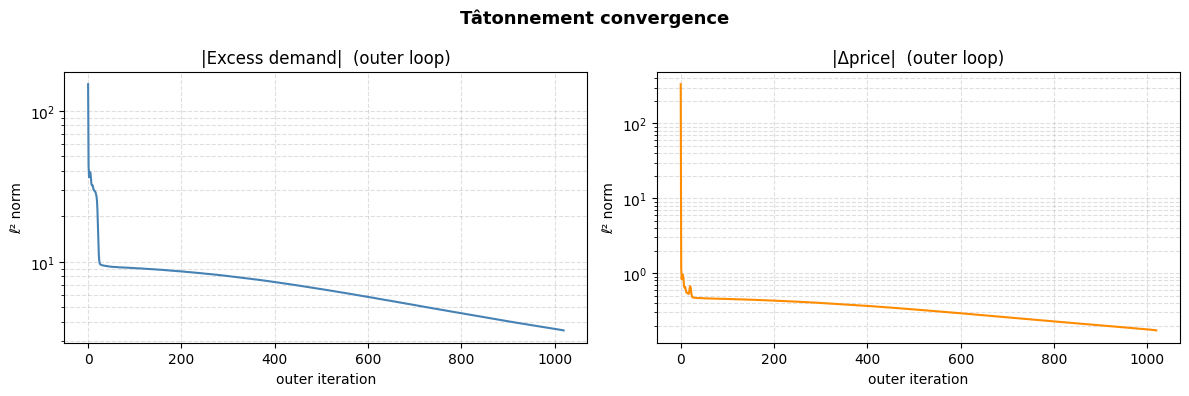

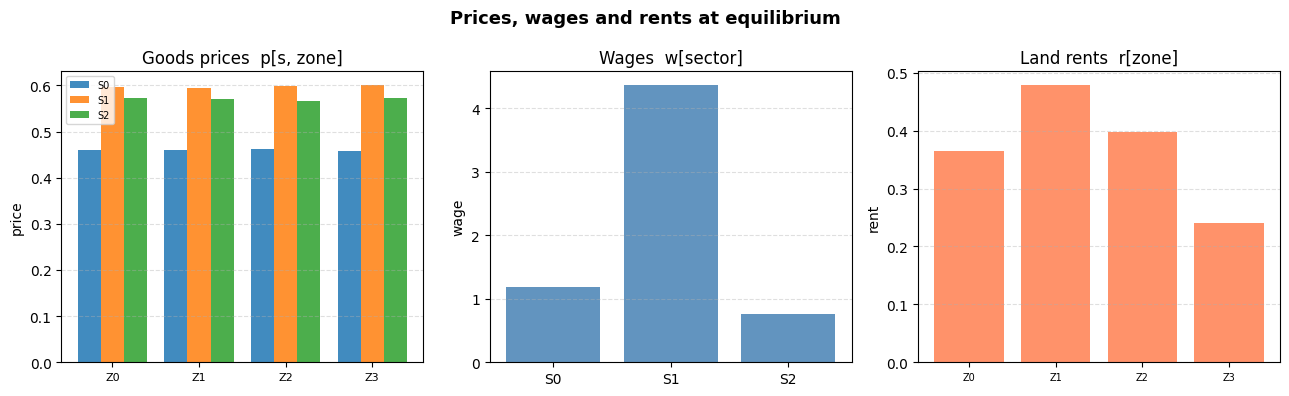

/tmp/ipykernel_1220875/1517500629.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


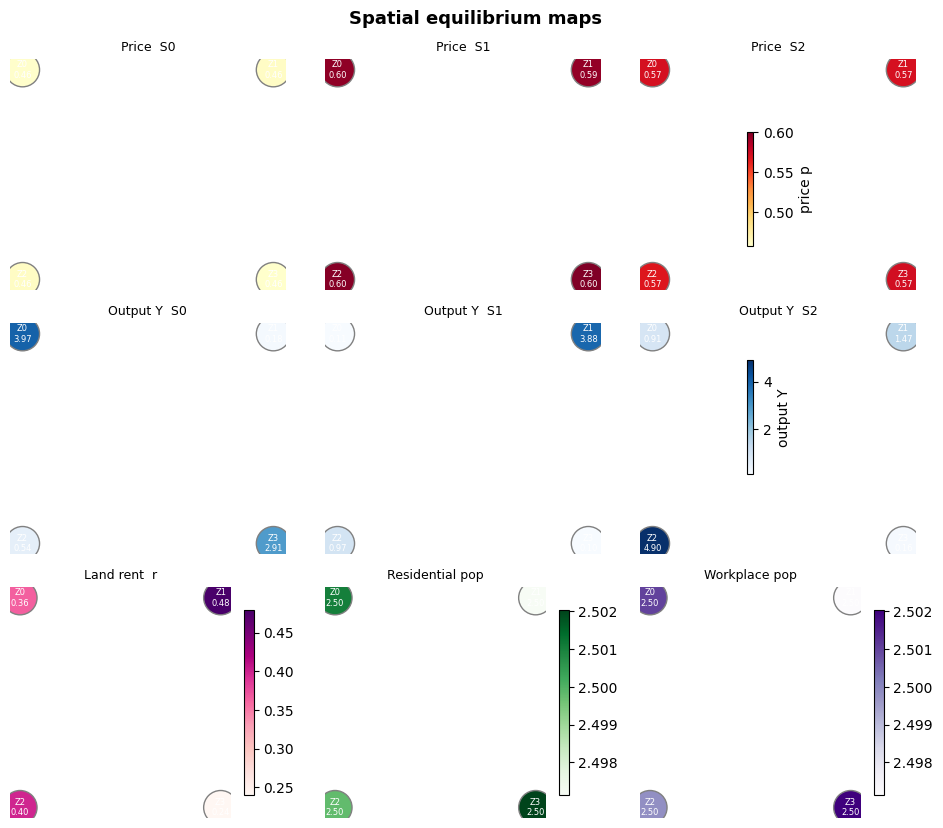

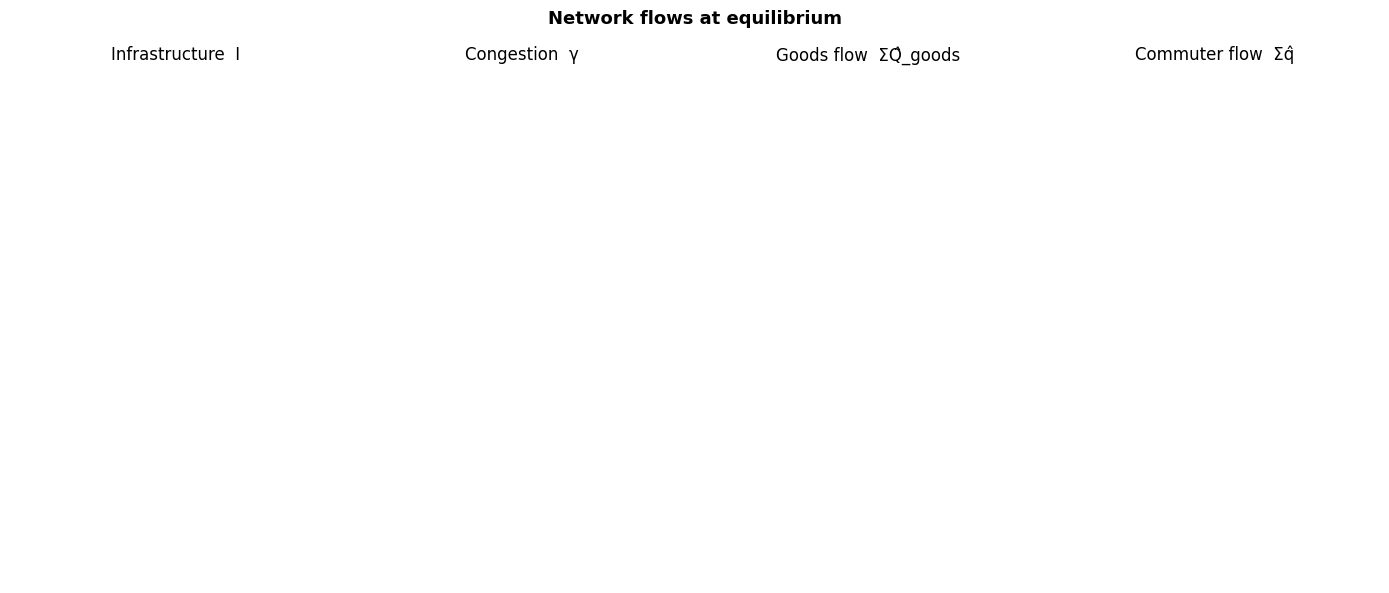

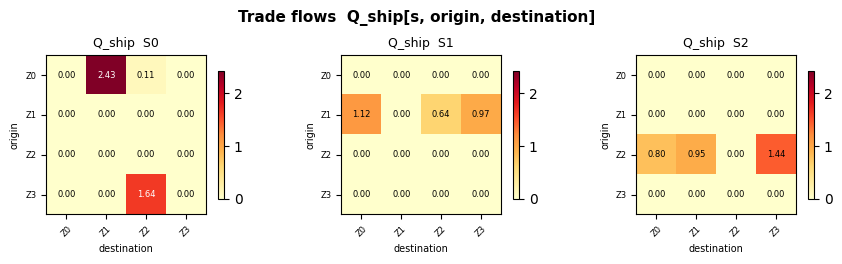

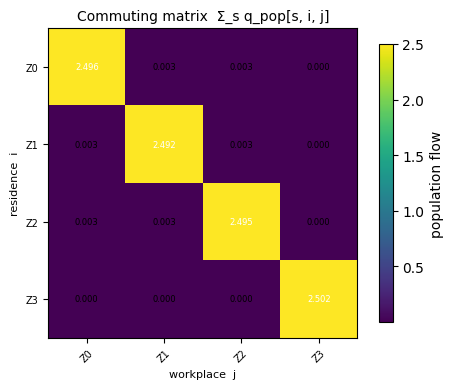

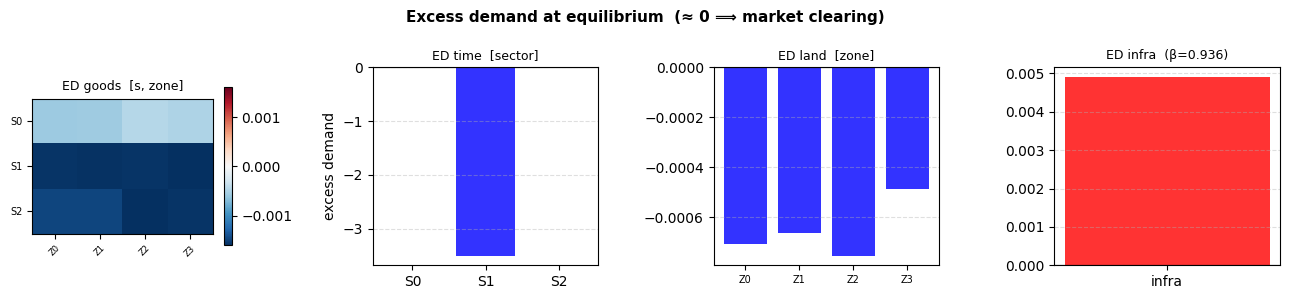


── Equilibrium summary ──────────────────────────────
  Sectors  : ['S0', 'S1', 'S2']
  Zones    : ['Z0', 'Z1', 'Z2', 'Z3']
  Wages    : [1.193  4.3642 0.7612]
  Rents    : [0.3644 0.4786 0.3977 0.2402]
  β (infra): 0.9361
  Σκ·I     : 10.0049  (budget K = 10)
  Off-diag commuting: 0.2%
  max |ED| goods : 1.61e-03
  max |ED| time  : 3.51e+00
  max |ED| land  : 7.55e-04
  |ED| infra     : 4.91e-03
────────────────────────────────────────────────────


In [170]:
viz = EquilibriumVisualizer(final_state, params, ed, solver)
viz.dashboard()

In [171]:
np.random.seed(42)

# ---- dimensions ----
S = 4                   # 0=agri, 1=manuf, 2=services, 3=energy
I_zones = 9             # 3x3 grid
n_nodes = 9             # zones sit directly on nodes

# ---- network: grid + diagonals to the CBD (Z4 = node 4) ----
# Grid connections (bidirectional):
grid_edges = [
    # south tier
    (0, 1), (1, 2),
    # middle tier
    (3, 4), (4, 5),
    # north tier
    (6, 7), (7, 8),
    # vertical
    (0, 3), (3, 6),
    (1, 4), (4, 7),
    (2, 5), (5, 8),
    # CBD diagonals (corner → CBD shortcuts)
    (0, 4), (2, 4), (6, 4), (8, 4),
]
edge_list = []
for a, b in grid_edges:
    edge_list += [(a, b), (b, a)]
n_edges = len(edge_list)

# Free-flow times: shorter on grid axes, longer on diagonals (more "rural")
T0 = np.ones(n_edges)
for k, (a, b) in enumerate(edge_list):
    if (a, b) in [(0,4),(4,0),(2,4),(4,2),(6,4),(4,6),(8,4),(4,8)]:
        T0[k] = 1.4   # diagonals ~ sqrt(2)

# Infra cost: CBD-adjacent edges expensive (denser to upgrade)
kappa = np.ones(n_edges)
for k, (a, b) in enumerate(edge_list):
    if 4 in (a, b):
        kappa[k] = 1.5

I_min = np.full(n_edges, 0.1)
I_max = np.full(n_edges, 5.0)

network = Network(
    n_nodes=n_nodes,
    edges=edge_list,
    kappa=kappa,
    I_min=I_min,
    I_max=I_max,
    zone_to_node=np.arange(I_zones),
)

In [172]:
# ---- utility ----
util = CobbDouglasUtility(
    alpha_c=np.array([
        [0.30, 0.20, 0.25, 0.15],   # agri-workers
        [0.20, 0.30, 0.25, 0.15],   # manuf-workers
        [0.20, 0.20, 0.35, 0.15],   # service-workers
        [0.20, 0.25, 0.25, 0.20],   # energy-workers
    ]),
    alpha_l=np.array([0.20, 0.20, 0.20, 0.20]),
    alpha_f=np.array([0.30, 0.30, 0.30, 0.10])
)

# ---- production: comparative advantage ----
# Z0,Z2,Z6,Z8 corners → agri
# Z4 CBD → manuf + services
# Z3,Z5 → manuf
# Z1,Z7 → services
# Z8 also strong in energy (peripheral resource zone)
A = np.array([
    # Z0   Z1   Z2   Z3   Z4   Z5   Z6   Z7   Z8
    [1.5, 0.7, 1.5, 0.9, 0.6, 0.9, 1.5, 0.7, 1.5],   # agri
    [0.7, 0.9, 0.7, 1.3, 1.6, 1.3, 0.7, 0.9, 0.7],   # manuf
    [0.6, 1.4, 0.6, 0.9, 1.5, 0.9, 0.6, 1.4, 0.6],   # services
    [0.8, 0.7, 0.8, 0.7, 0.7, 0.7, 0.8, 0.7, 1.6],   # energy (Z8 dominant)
])

prod = QuadraticProduction(
    A=A,
    alpha_H=np.array([2.0, 2.0, 2.0, 2.0]),
    alpha_L=np.array([1.5, 0.8, 0.5, 1.0]),   # agri very land-intensive
    alpha_Q=np.array([
        [0.0, 0.6, 0.5, 0.7],     # agri uses manuf, services, energy
        [0.8, 0.0, 0.7, 0.9],     # manuf uses everything
        [0.5, 0.6, 0.0, 0.6],     # services
        [0.4, 0.7, 0.5, 0.0],     # energy
    ]),
    beta_H=np.array([1.0, 1.0, 1.0, 1.0]),
    beta_L=np.array([1.0, 1.0, 1.0, 1.0]),
    beta_Q=np.ones((S, S)),
)

# ---- transport ----
tau_fn  = IcebergTau(delta=np.array([0.04, 0.05, 0.08, 0.06]))
# services more perishable, agri robust
time_fn = BPRTime(T0=T0, a=0.15, b=4.0)

# ---- endowments: corners have more land, CBD scarce ----
L_bar = np.array([3.0, 2.0, 3.0,
                  2.5, 1.0, 2.5,    # CBD has only 1.0
                  3.0, 2.0, 3.0])

params = ModelParams(
    n_zones=I_zones, n_sectors=S,
    production_function=prod,
    utility_function=util,
    L_bar=L_bar,
    H_bar=1.0,
    q_bar=20.0,                  # 20 units of population
    K=18.0,                      # tight infra budget
    tau_link=tau_fn,
    t_link=time_fn,
    d_w=20,
    phi=np.array([1.0, 2.0, 0.5, 1.5]),   # manuf heavy, energy heavy, services light
    sigma=np.array([1.0, 1.0, 1.0, 1.0]),
    sigma_tilde=2.0,
    network=network,
)

hyperparams = AlgoParams(
    T_outer=1000, T_inner=20,
    eta_p=0.04, eta_w=0.04, eta_r=0.04, eta_beta=0.05, eta_I=0.02,
    alpha_Q=0.15, alpha_Qhat=0.30, eta_gamma=0.04,
    tol_outer=1e-5, tol_inner=1e-6,
    verbose=True, log_every=100, decay_start=1000, decay_type='linear'
)

In [173]:
state0 = make_initial_state(params)

In [174]:
ed = ExcessDemand()
pu = PriceUpdater(ed)
solver = UrbanModelSolver(
    HouseholdBlock(), ProductionBlock(), TransportBlock(),
    InfrastructureBlock(), ed, pu,
)
final_state = solver.solve(state0, params, hyperparams)

[outer    0] |ED|=4.8966e+01  |Δprice|=1.0539e+00
[outer  100] |ED|=1.8324e-01  |Δprice|=3.3857e-03
[outer  200] |ED|=1.1684e-02  |Δprice|=4.7245e-04
[outer  300] |ED|=1.0467e-02  |Δprice|=4.5279e-04
[outer  400] |ED|=9.5505e-03  |Δprice|=4.3992e-04
[outer  500] |ED|=8.8057e-03  |Δprice|=4.2569e-04
[outer  600] |ED|=8.2101e-03  |Δprice|=3.9925e-04
[outer  700] |ED|=7.7103e-03  |Δprice|=3.7646e-04
[outer  800] |ED|=7.2900e-03  |Δprice|=3.5692e-04
[outer  900] |ED|=6.9292e-03  |Δprice|=3.4002e-04


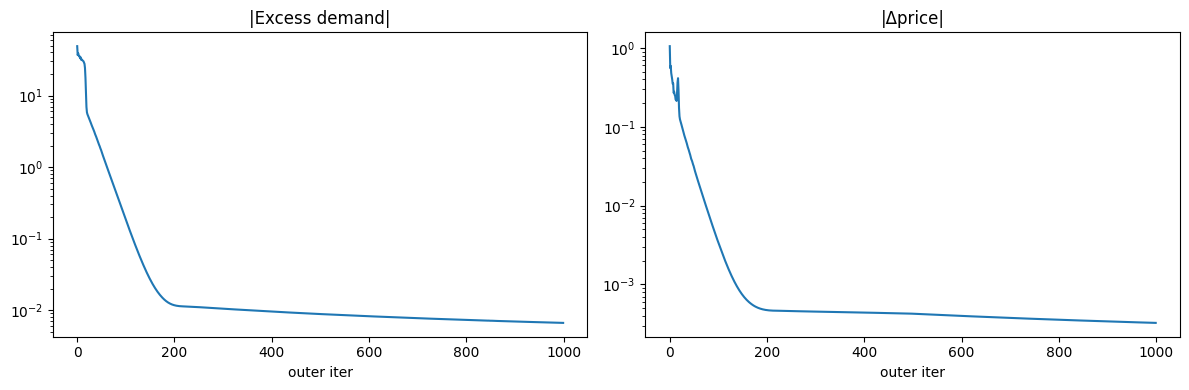


=== Prices p (sector × zone) ===
[[0.247 0.252 0.247 0.25  0.252 0.249 0.247 0.252 0.243]
 [0.385 0.383 0.385 0.375 0.372 0.373 0.385 0.383 0.38 ]
 [0.491 0.492 0.497 0.493 0.494 0.493 0.499 0.494 0.5  ]
 [0.374 0.378 0.372 0.376 0.37  0.369 0.371 0.369 0.362]]

=== Output Y (sector × zone) ===
[[4.907 0.027 4.897 0.482 0.    0.475 4.9   0.026 4.537]
 [0.    0.676 0.    3.122 5.278 3.131 0.    0.673 0.   ]
 [0.    3.131 0.    0.503 3.786 0.506 0.    3.16  0.   ]
 [0.796 0.443 0.789 0.444 0.41  0.412 0.784 0.409 5.487]]

=== Population ===
by sector : [5.018 4.748 4.737 5.497]
by residence : [2.25  2.244 2.246 2.27  2.034 2.281 2.246 2.253 2.177]
by workplace : [2.25  2.244 2.246 2.27  2.034 2.281 2.246 2.253 2.177]

=== Wages w ===: [0.437 0.547 0.736 0.395]
=== Rents r ===  : [0.263 0.258 0.262 0.254 0.445 0.254 0.262 0.258 0.321]
=== Σκ·I = 18.006, K = 18.0
=== β = 1.1879

=== I_infra by edge ===
edge             I         γ     q_hat     goods
(0,1)       0.578    0.0172     0.000 

In [175]:
hist_ed = solver.logger.history['excess_demand']
hist_dp = solver.logger.history['price_changes']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(hist_ed); ax[0].set_title('|Excess demand|'); ax[0].set_xlabel('outer iter')
ax[1].semilogy(hist_dp); ax[1].set_title('|Δprice|');         ax[1].set_xlabel('outer iter')
plt.tight_layout(); plt.show()

zones = ['Z0', 'Z1', 'Z2', 'Z3', 'Z4(CBD)', 'Z5', 'Z6', 'Z7', 'Z8']
sectors = ['agri', 'manuf', 'srv', 'energy']

print("\n=== Prices p (sector × zone) ===")
print(np.array2string(final_state.p, precision=3))

print("\n=== Output Y (sector × zone) ===")
print(np.array2string(final_state.Y, precision=3))

print("\n=== Population ===")
print("by sector :", np.round(final_state.q_pop.sum(axis=(1,2)), 3))
print("by residence :", np.round(final_state.q_pop.sum(axis=(0,2)), 3))
print("by workplace :", np.round(final_state.q_pop.sum(axis=(0,1)), 3))

print("\n=== Wages w ===:", np.round(final_state.w, 3))
print("=== Rents r ===  :", np.round(final_state.r, 3))
print(f"=== Σκ·I = {(network.kappa * final_state.I_infra).sum():.3f}, K = {params.K}")
print(f"=== β = {final_state.beta:.4f}")

print("\n=== I_infra by edge ===")
print(f"{'edge':<10}{'I':>8}{'γ':>10}{'q_hat':>10}{'goods':>10}")
q_hat_total = final_state.q_hat_s.sum(axis=0)
goods_total = final_state.Q_hat_s_goods.sum(axis=0)
for e, (a, b) in enumerate(edge_list):
    print(f"({a},{b}){' ':4}{final_state.I_infra[e]:8.3f}{final_state.gamma[e]:10.4f}"
          f"{q_hat_total[e]:10.3f}{goods_total[e]:10.3f}")

print("\n=== Trade flows by sector (out-degree per origin) ===")
for s in range(S):
    print(f"\n{sectors[s]} (Q_ship[s].sum(axis=1)):")
    print(np.array2string(final_state.Q_ship[s].sum(axis=1), precision=3))

print("\n=== max |ED| per market ===")
print(f"  goods: {np.abs(ed.ED_goods).max():.2e}")
print(f"  time : {np.abs(ed.ED_time).max():.2e}")
print(f"  land : {np.abs(ed.ED_land).max():.2e}")
print(f"  infra: {abs(ed.ED_infra):.2e}")
print("\n=== ED_goods matrix ===")
print(np.array2string(ed.ED_goods, precision=4, suppress_small=True))

  EQUILIBRIUM DASHBOARD


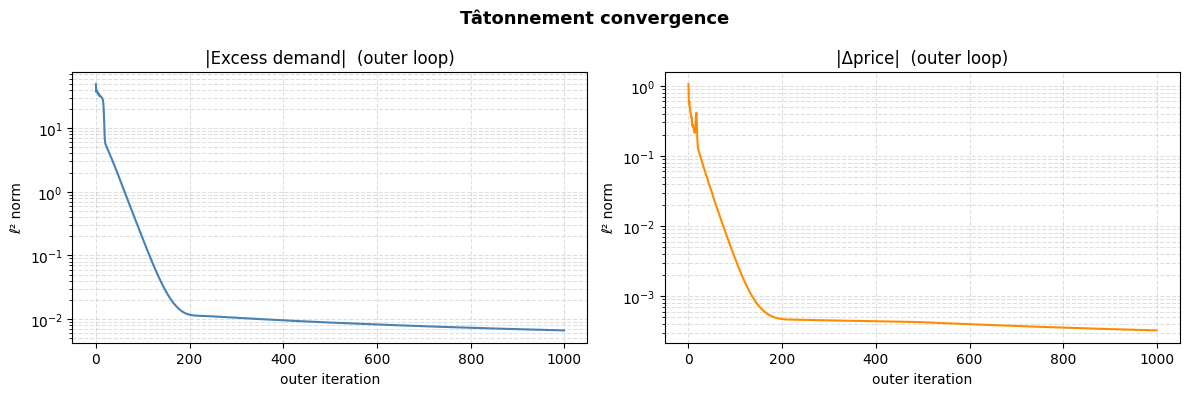

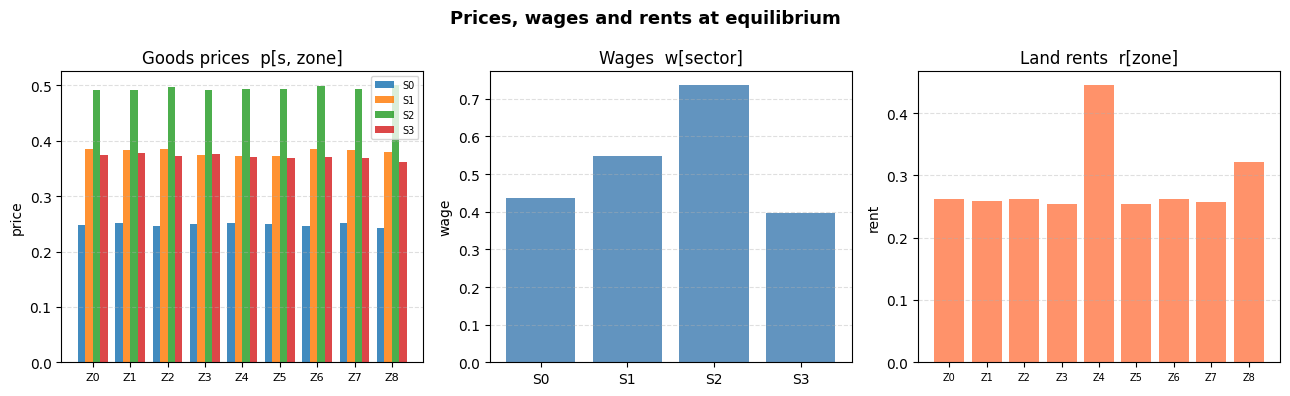

/tmp/ipykernel_1220875/1517500629.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


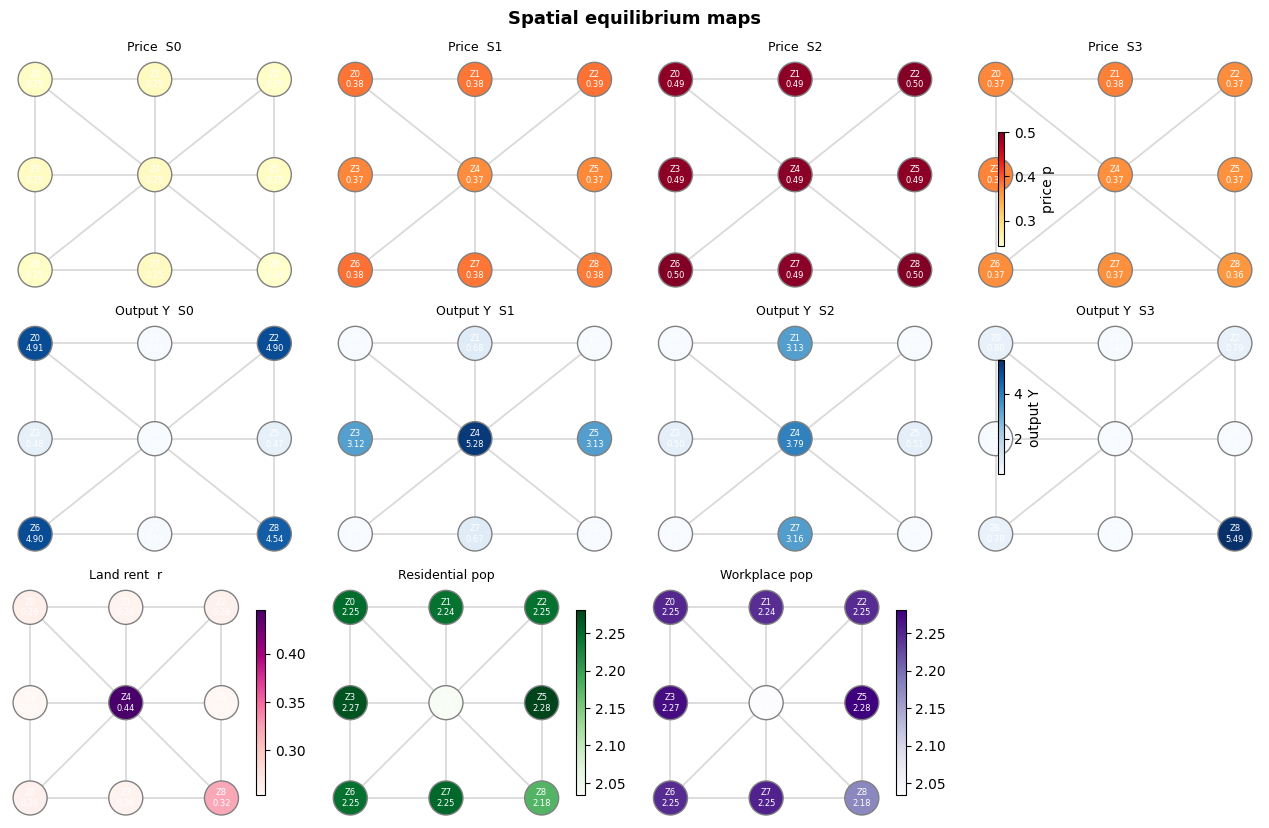

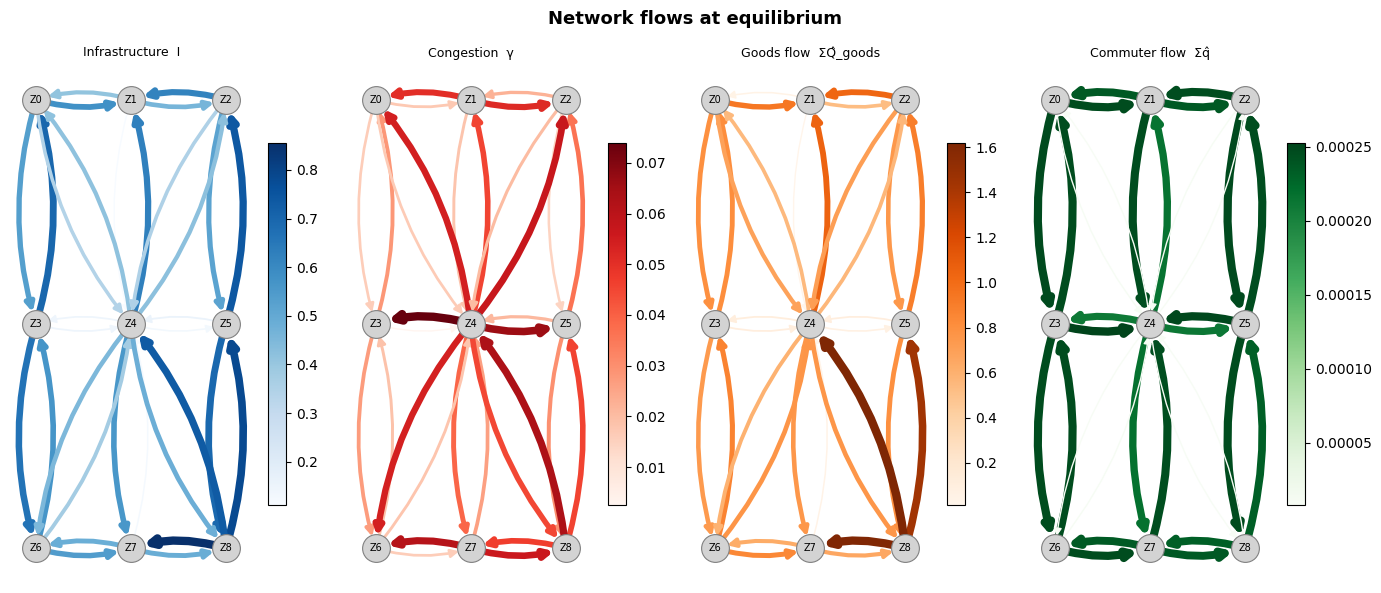

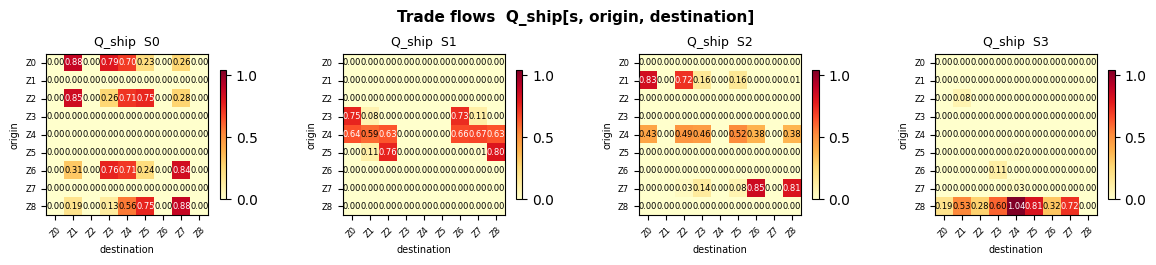

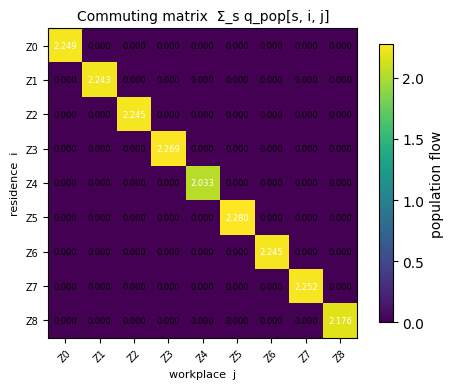

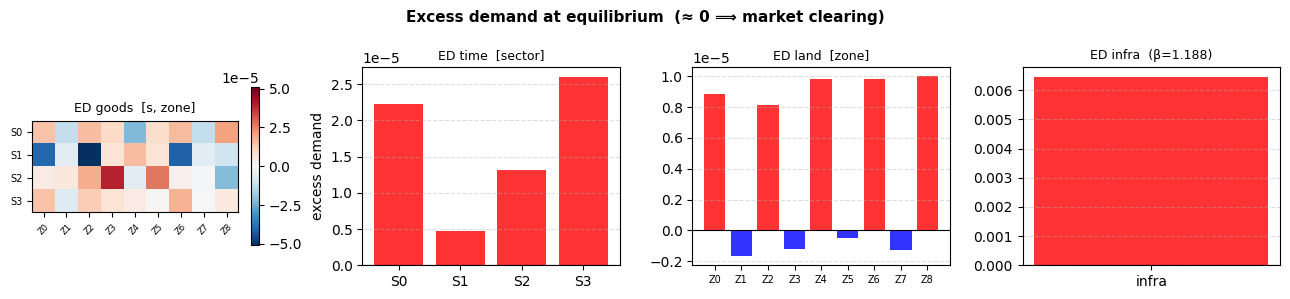


── Equilibrium summary ──────────────────────────────
  Sectors  : ['S0', 'S1', 'S2', 'S3']
  Zones    : ['Z0', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5', 'Z6', 'Z7', 'Z8']
  Wages    : [0.4371 0.5474 0.7363 0.3954]
  Rents    : [0.2626 0.2584 0.2619 0.2545 0.4447 0.2538 0.2618 0.2578 0.3208]
  β (infra): 1.1879
  Σκ·I     : 18.0065  (budget K = 18.0)
  Off-diag commuting: 0.0%
  max |ED| goods : 5.10e-05
  max |ED| time  : 2.60e-05
  max |ED| land  : 1.00e-05
  |ED| infra     : 6.46e-03
────────────────────────────────────────────────────


In [176]:
viz = EquilibriumVisualizer(final_state, params, ed, solver)
viz.dashboard()

## Example 3 (bis) with another production function (Cobb Douglas)

In [177]:
np.random.seed(42)

# ---- dimensions ----
S = 4                   # 0=agri, 1=manuf, 2=services, 3=energy
I_zones = 9             # 3x3 grid
n_nodes = 9             # zones sit directly on nodes

# ---- network: grid + diagonals to the CBD (Z4 = node 4) ----
# Grid connections (bidirectional):
grid_edges = [
    # south tier
    (0, 1), (1, 2),
    # middle tier
    (3, 4), (4, 5),
    # north tier
    (6, 7), (7, 8),
    # vertical
    (0, 3), (3, 6),
    (1, 4), (4, 7),
    (2, 5), (5, 8),
    # CBD diagonals (corner → CBD shortcuts)
    (0, 4), (2, 4), (6, 4), (8, 4),
]
edge_list = []
for a, b in grid_edges:
    edge_list += [(a, b), (b, a)]
n_edges = len(edge_list)

# Free-flow times: shorter on grid axes, longer on diagonals (more "rural")
T0 = np.ones(n_edges)
for k, (a, b) in enumerate(edge_list):
    if (a, b) in [(0,4),(4,0),(2,4),(4,2),(6,4),(4,6),(8,4),(4,8)]:
        T0[k] = 1.4   # diagonals ~ sqrt(2)

# Infra cost: CBD-adjacent edges expensive (denser to upgrade)
kappa = np.ones(n_edges)
for k, (a, b) in enumerate(edge_list):
    if 4 in (a, b):
        kappa[k] = 1.5

I_min = np.full(n_edges, 0.1)
I_max = np.full(n_edges, 5.0)

network = Network(
    n_nodes=n_nodes,
    edges=edge_list,
    kappa=kappa,
    I_min=I_min,
    I_max=I_max,
    zone_to_node=np.arange(I_zones),
)


In [178]:
# ---- utility ----
util = CobbDouglasUtility(
    alpha_c=np.array([
        [0.30, 0.20, 0.25, 0.15],   # agri-workers
        [0.20, 0.30, 0.25, 0.15],   # manuf-workers
        [0.20, 0.20, 0.35, 0.15],   # service-workers
        [0.20, 0.25, 0.25, 0.20],   # energy-workers
    ]),
    alpha_l=np.array([0.20, 0.20, 0.20, 0.20]),
    alpha_f=np.array([0.30, 0.30, 0.30, 0.10])
)

# ---- production: comparative advantage ----
# Z0,Z2,Z6,Z8 corners → agri
# Z4 CBD → manuf + services
# Z3,Z5 → manuf
# Z1,Z7 → services
# Z8 also strong in energy (peripheral resource zone)
A = np.array([
    # Z0   Z1   Z2   Z3   Z4   Z5   Z6   Z7   Z8
    [1.5, 0.7, 1.5, 0.9, 0.6, 0.9, 1.5, 0.7, 1.5],   # agri
    [0.7, 0.9, 0.7, 1.3, 1.6, 1.3, 0.7, 0.9, 0.7],   # manuf
    [0.6, 1.4, 0.6, 0.9, 1.5, 0.9, 0.6, 1.4, 0.6],   # services
    [0.8, 0.7, 0.8, 0.7, 0.7, 0.7, 0.8, 0.7, 1.6],   # energy (Z8 dominant)
])

prod = CobbDouglasProduction(
    A=A,
    # Human-capital elasticity: modest, sector-specific
    aH = np.array([0.10,   # agri:     low skill intensity
                   0.20,   # manuf:    moderate
                   0.25,   # services: most skill-intensive
                   0.15]), # energy:   capital-driven, low skill

    # Land / raw-labour elasticity
    aL = np.array([0.30,   # agri:     very land/labour intensive
                   0.15,   # manuf:    moderate
                   0.10,   # services: least land-intensive
                   0.20]), # energy:   needs physical labour

    # Intermediate-input elasticity matrix aQ[s, k]
    # Diagonal must stay 0 (sector does not use its own output as input here)
    # Each ROW must satisfy: aH[s] + aL[s] + sum(aQ[s,:]) < 1
    #
    # Remaining "budget" per sector:
    #   agri:     1 - 0.10 - 0.30 = 0.60  → spread across manuf/services/energy
    #   manuf:    1 - 0.20 - 0.15 = 0.65  → uses agri/services/energy
    #   services: 1 - 0.25 - 0.10 = 0.65  → uses agri/manuf/energy
    #   energy:   1 - 0.15 - 0.20 = 0.65  → uses agri/manuf/services
    aQ = np.array([
        [0.00, 0.20, 0.15, 0.20],   # agri:     Σ = 0.10+0.30+0.55 = 0.95 < 1 ✓
        [0.20, 0.00, 0.20, 0.20],   # manuf:    Σ = 0.20+0.15+0.60 = 0.95 < 1 ✓
        [0.15, 0.25, 0.00, 0.20],   # services: Σ = 0.25+0.10+0.60 = 0.95 < 1 ✓
        [0.15, 0.25, 0.20, 0.00],   # energy:   Σ = 0.15+0.20+0.60 = 0.95 < 1 ✓
    ])
)

# ---- transport ----
tau_fn  = IcebergTau(delta=np.array([0.04, 0.05, 0.08, 0.06]))
# services more perishable, agri robust
time_fn = BPRTime(T0=T0, a=0.15, b=4.0)

# ---- endowments: corners have more land, CBD scarce ----
L_bar = np.array([3.0, 2.0, 3.0,
                  2.5, 1.0, 2.5,    # CBD has only 1.0
                  3.0, 2.0, 3.0])

params = ModelParams(
    n_zones=I_zones, n_sectors=S,
    production_function=prod,
    utility_function=util,
    L_bar=L_bar,
    H_bar=1.0,
    q_bar=20.0,                  # 20 units of population
    K=18.0,                      # tight infra budget
    tau_link=tau_fn,
    t_link=time_fn,
    d_w=20,
    phi=np.array([1.0, 2.0, 0.5, 1.5]),   # manuf heavy, energy heavy, services light
    sigma=np.array([1.0, 1.0, 1.0, 1.0]),
    sigma_tilde=2.0,
    network=network,
)

hyperparams = AlgoParams(
    T_outer=10000, T_inner=20,
    eta_p=0.04, eta_w=0.04, eta_r=0.04, eta_beta=0.05, eta_I=0.02,
    alpha_Q=0.15, alpha_Qhat=0.30, eta_gamma=0.04,
    tol_outer=1e-5, tol_inner=1e-6,
    verbose=True, log_every=100, decay_start=6000, decay_type=None
)

In [179]:
state0 = make_initial_state(params)

In [180]:
np.random.seed(42)

ed = ExcessDemand()
pu = PriceUpdater(ed)
solver = UrbanModelSolver(
    HouseholdBlock(), ProductionBlock(), TransportBlock(),
    InfrastructureBlock(), ed, pu,
)
final_state = solver.solve(state0, params, hyperparams)

[outer    0] |ED|=4.1445e+01  |Δprice|=7.2861e-01
[outer  100] |ED|=1.4078e+00  |Δprice|=5.3472e-02
[outer  200] |ED|=1.0226e+00  |Δprice|=3.9104e-02
[outer  300] |ED|=8.3262e-01  |Δprice|=3.1986e-02
[outer  400] |ED|=7.4094e-01  |Δprice|=2.7824e-02
[outer  500] |ED|=6.4314e-01  |Δprice|=2.4215e-02
[outer  600] |ED|=5.6920e-01  |Δprice|=2.1339e-02
[outer  700] |ED|=5.0641e-01  |Δprice|=1.9108e-02
[outer  800] |ED|=4.6470e-01  |Δprice|=1.7297e-02
[outer  900] |ED|=4.1460e-01  |Δprice|=1.5762e-02
[outer 1000] |ED|=3.9624e-01  |Δprice|=1.4794e-02
[outer 1100] |ED|=3.9486e-01  |Δprice|=1.4351e-02
[outer 1200] |ED|=3.3593e-01  |Δprice|=1.2864e-02
[outer 1300] |ED|=3.1137e-01  |Δprice|=1.1858e-02
[outer 1400] |ED|=2.9457e-01  |Δprice|=1.1105e-02
[outer 1500] |ED|=2.7297e-01  |Δprice|=1.0238e-02
[outer 1600] |ED|=2.5357e-01  |Δprice|=9.6909e-03
[outer 1700] |ED|=2.4167e-01  |Δprice|=9.2807e-03
[outer 1800] |ED|=2.2980e-01  |Δprice|=8.7632e-03
[outer 1900] |ED|=2.1882e-01  |Δprice|=8.2284e-03


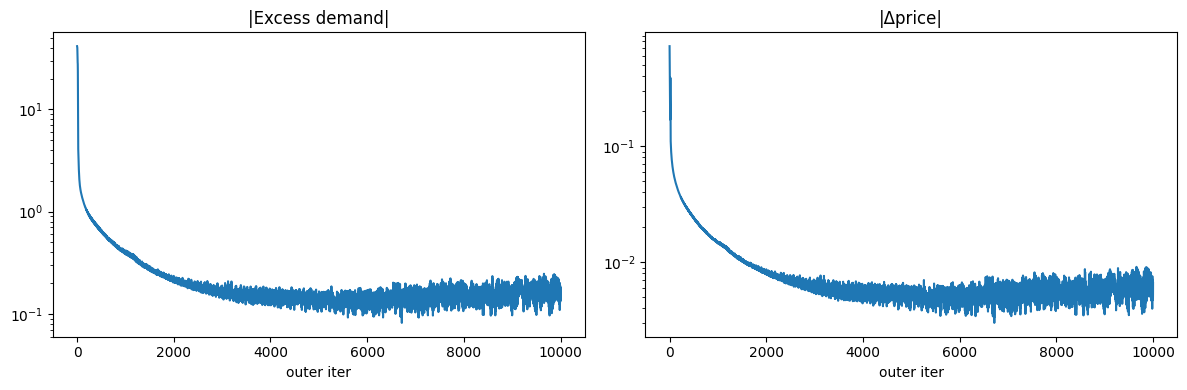


=== Prices p (sector × zone) ===
[[ 8.596  8.605  8.596  8.605  8.604  8.604  8.597  8.604  8.613]
 [11.924 11.936 11.935 11.91  11.92  11.921 11.925 11.933 11.936]
 [11.747 11.735 11.747 11.759 11.739 11.764 11.753 11.736 11.749]
 [11.069 11.072 11.065 11.072 11.051 11.048 11.063 11.05  11.034]]

=== Output Y (sector × zone) ===
[[0.364 0.    0.364 0.    0.    0.    0.363 0.    0.019]
 [0.    0.    0.    0.262 0.412 0.264 0.    0.    0.   ]
 [0.    0.365 0.    0.    0.171 0.    0.    0.366 0.   ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.833]]

=== Population ===
by sector : [5.28  4.672 4.736 5.311]
by residence : [2.265 2.29  2.265 2.366 1.851 2.363 2.264 2.289 2.049]
by workplace : [2.265 2.289 2.265 2.363 1.857 2.361 2.264 2.288 2.049]

=== Wages w ===: [0.258 0.48  0.558 0.298]
=== Rents r ===  : [0.464 0.443 0.463 0.376 1.305 0.378 0.464 0.444 0.764]
=== Σκ·I = 18.001, K = 18.0
=== β = 2.0268

=== I_infra by edge ===
edge             I         γ     q_hat     goods
(0

In [181]:
hist_ed = solver.logger.history['excess_demand']
hist_dp = solver.logger.history['price_changes']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(hist_ed); ax[0].set_title('|Excess demand|'); ax[0].set_xlabel('outer iter')
ax[1].semilogy(hist_dp); ax[1].set_title('|Δprice|');         ax[1].set_xlabel('outer iter')
plt.tight_layout(); plt.show()

zones = ['Z0', 'Z1', 'Z2', 'Z3', 'Z4(CBD)', 'Z5', 'Z6', 'Z7', 'Z8']
sectors = ['agri', 'manuf', 'srv', 'energy']

print("\n=== Prices p (sector × zone) ===")
print(np.array2string(final_state.p, precision=3))

print("\n=== Output Y (sector × zone) ===")
print(np.array2string(final_state.Y, precision=3))

print("\n=== Population ===")
print("by sector :", np.round(final_state.q_pop.sum(axis=(1,2)), 3))
print("by residence :", np.round(final_state.q_pop.sum(axis=(0,2)), 3))
print("by workplace :", np.round(final_state.q_pop.sum(axis=(0,1)), 3))

print("\n=== Wages w ===:", np.round(final_state.w, 3))
print("=== Rents r ===  :", np.round(final_state.r, 3))
print(f"=== Σκ·I = {(network.kappa * final_state.I_infra).sum():.3f}, K = {params.K}")
print(f"=== β = {final_state.beta:.4f}")

print("\n=== I_infra by edge ===")
print(f"{'edge':<10}{'I':>8}{'γ':>10}{'q_hat':>10}{'goods':>10}")
q_hat_total = final_state.q_hat_s.sum(axis=0)
goods_total = final_state.Q_hat_s_goods.sum(axis=0)
for e, (a, b) in enumerate(edge_list):
    print(f"({a},{b}){' ':4}{final_state.I_infra[e]:8.3f}{final_state.gamma[e]:10.4f}"
          f"{q_hat_total[e]:10.3f}{goods_total[e]:10.3f}")

print("\n=== Trade flows by sector (out-degree per origin) ===")
for s in range(S):
    print(f"\n{sectors[s]} (Q_ship[s].sum(axis=1)):")
    print(np.array2string(final_state.Q_ship[s].sum(axis=1), precision=3))

print("\n=== max |ED| per market ===")
print(f"  goods: {np.abs(ed.ED_goods).max():.2e}")
print(f"  time : {np.abs(ed.ED_time).max():.2e}")
print(f"  land : {np.abs(ed.ED_land).max():.2e}")
print(f"  infra: {abs(ed.ED_infra):.2e}")
print("\n=== ED_goods matrix ===")
print(np.array2string(ed.ED_goods, precision=4, suppress_small=True))

  EQUILIBRIUM DASHBOARD


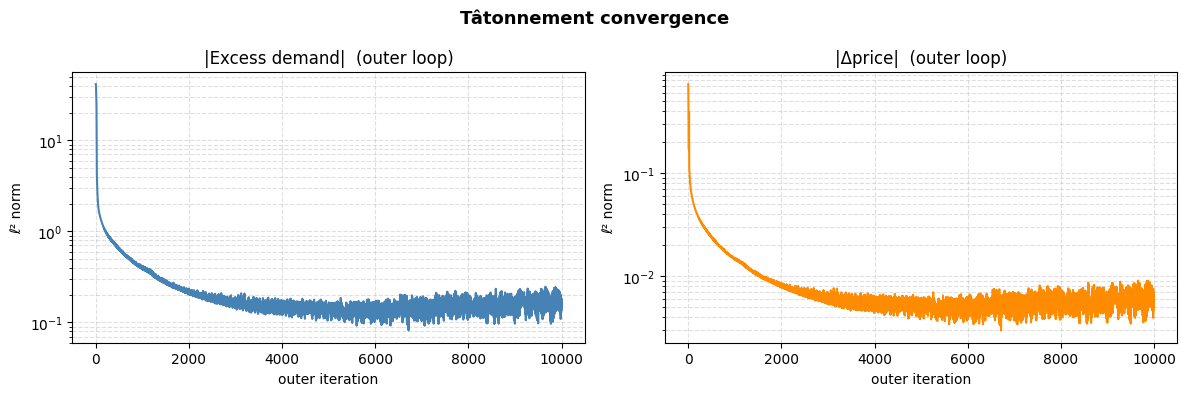

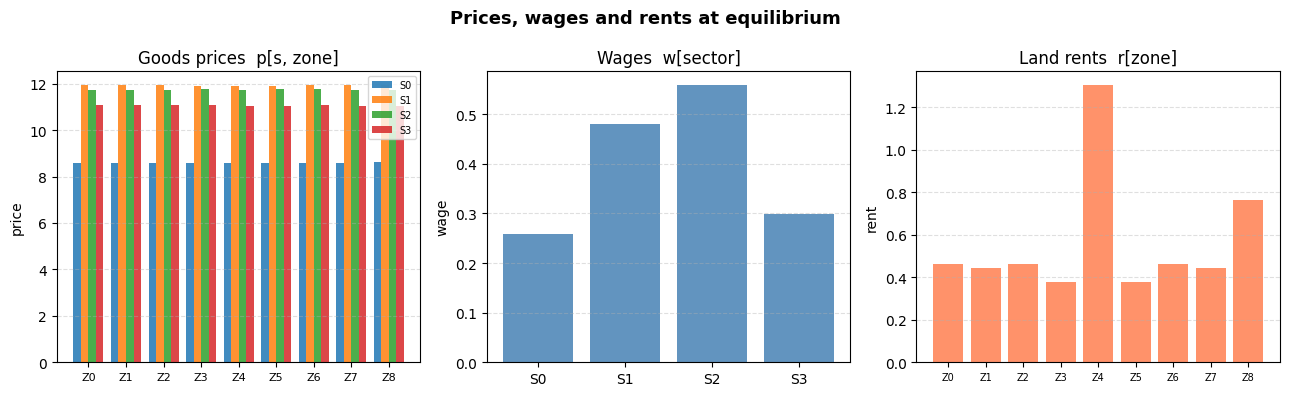

/tmp/ipykernel_1220875/1517500629.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


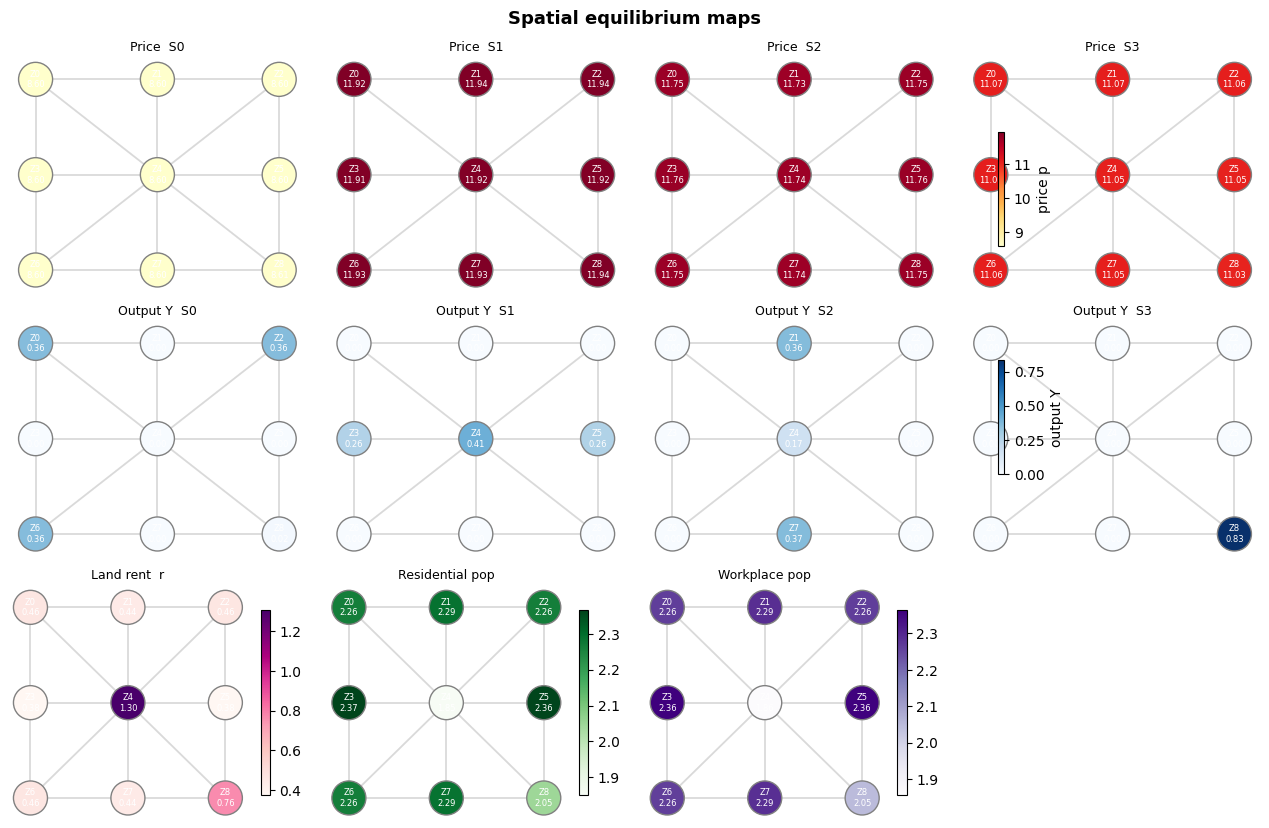

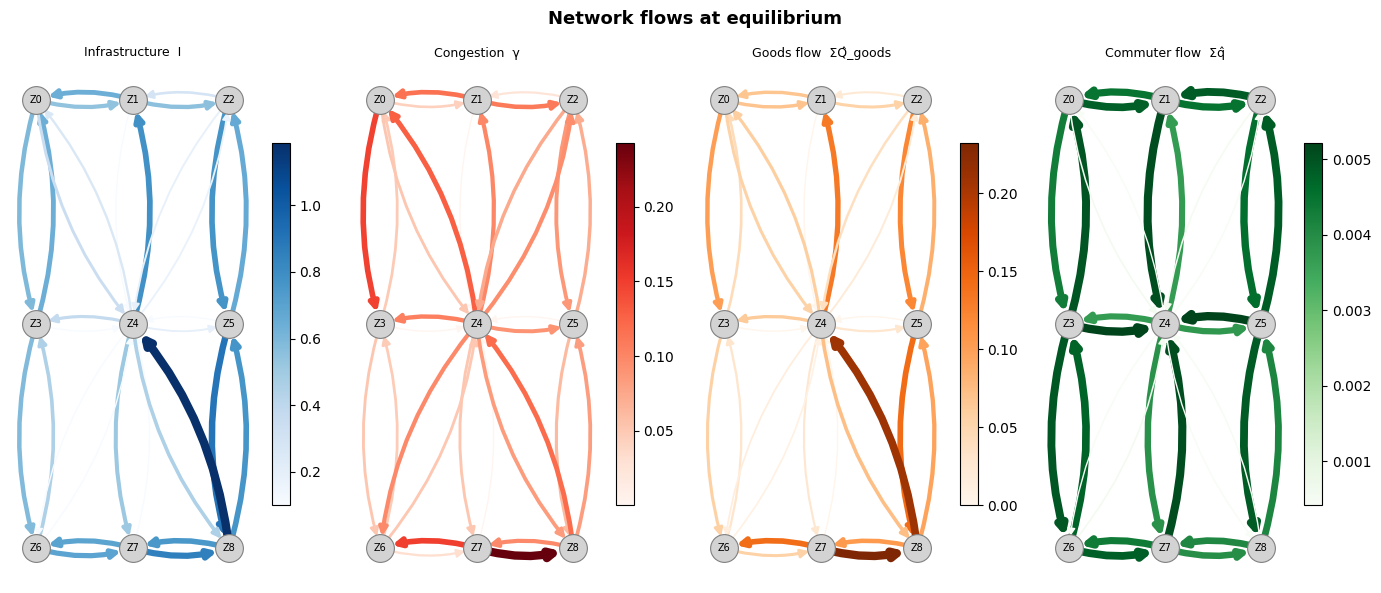

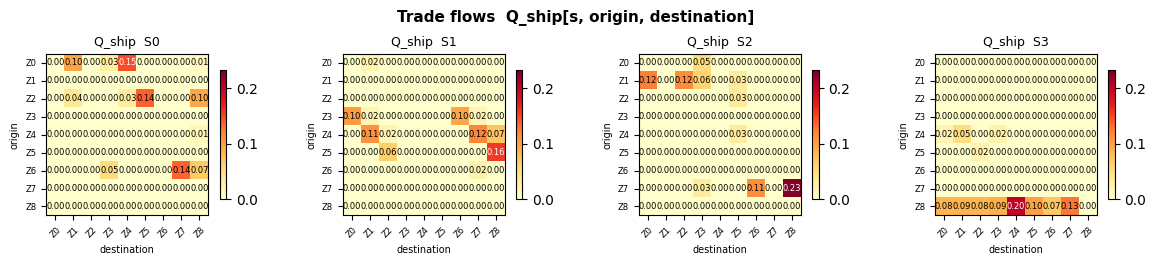

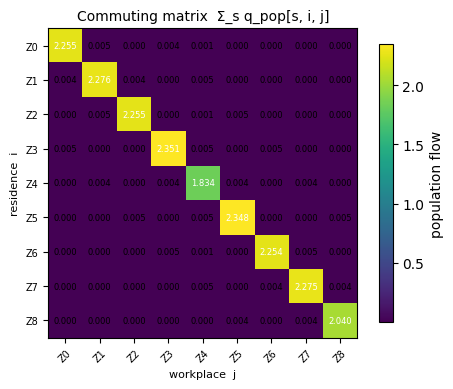

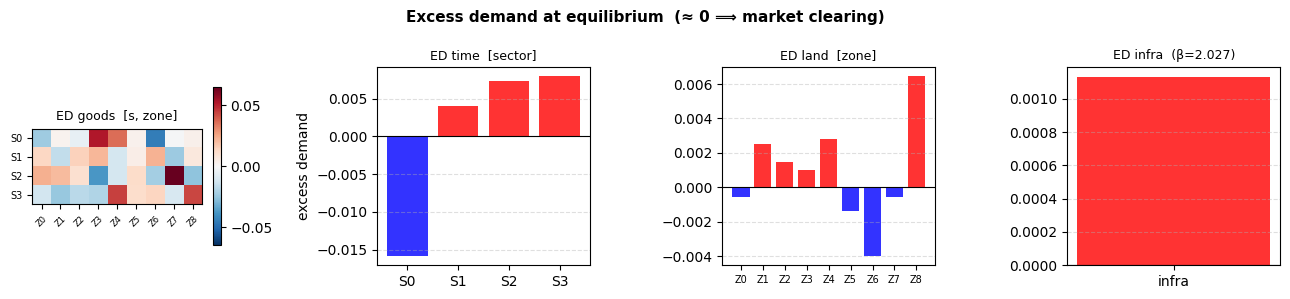


── Equilibrium summary ──────────────────────────────
  Sectors  : ['S0', 'S1', 'S2', 'S3']
  Zones    : ['Z0', 'Z1', 'Z2', 'Z3', 'Z4', 'Z5', 'Z6', 'Z7', 'Z8']
  Wages    : [0.2579 0.4799 0.5584 0.2984]
  Rents    : [0.4637 0.4426 0.4634 0.3762 1.3047 0.3782 0.464  0.4437 0.7643]
  β (infra): 2.0268
  Σκ·I     : 18.0011  (budget K = 18.0)
  Off-diag commuting: 0.6%
  max |ED| goods : 6.50e-02
  max |ED| time  : 1.59e-02
  max |ED| land  : 6.45e-03
  |ED| infra     : 1.13e-03
────────────────────────────────────────────────────


In [184]:
viz = EquilibriumVisualizer(final_state, params, ed, solver)
viz.dashboard()